<a href="https://colab.research.google.com/github/Patch85/AI-Search/blob/master/Premkumar_Krishnamurthy_Dillon_John_Matthew_Dillon_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CNN-LSTM Network Intrusion Detection System

**Team:**
* Premkumar Krishnamurthy
* Dillon John
* Matthew Dillon

**Course:** AI 570 – Deep Learning (Fall, 2025)

### Problem Statement
* This project aims to build a viable network intrusion detection system by applying Convolutional Long Short-Term Memories (C-LSTMs) to the UNSW-NB15 network traffice dataset.
    
    
    
* **Keywords:** Network Intrusion Detection, Cybersecurity, C-LSTM


### Data Collection
* Source(url): https://research.unsw.edu.au/projects/unsw-nb15-dataset
* Short Description: A dataset of raw network packets captured by UNSW researchers and labeled with normal / abnormal as well as 9 different attack type labels.

* Keywords: Cybersecurity, Network Traffic, Network Intrusion Detection

### Required packages

* Add instructions to install the required packages


In [ ]:
# Install required packages
!pip install imbalanced-learn pandas numpy scikit-learn matplotlib seaborn plotly tensorflow -q

In [ ]:
# Set all possible random seeds to ensure reproducibility of the modeling experiments

import numpy as np
import tensorflow as tf
import random as rn
import os

seed_value = 42

rn.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
os.environ['PYTHONHASHSEED'] = str(seed_value)

### Data Preprocessing

1. Setup and Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Cleaning
4. Feature Engineering
5. Handling Class Imbalance (SMOTE)
6. Feature Scaling and Normalization
7. Temporal Sequence Creation for LSTM
8. Final Data Preparation
9. Save Preprocessed Data


### 1. Setup and Data Loading

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load UNSW-NB15 dataset from Google Drive
import zipfile
import os

# Your exact file path
zip_path = '/content/drive/MyDrive/Colab Notebooks/Penn State Deep Learning/UNSW_NB15_Data_Analysis_Preprocessing.zip'

print("="*70)
print("Loading UNSW-NB15 Dataset from Google Drive")
print("="*70)

# Check if file exists
if os.path.exists(zip_path):
    file_size = os.path.getsize(zip_path) / (1024 * 1024)
    print(f"File found!")
    print(f"   Location: {zip_path}")
    print(f"   Size: {file_size:.2f} MB\n")

    # Extract
    print("📦 Extracting files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/unsw_nb15_data')

    print("Extraction complete!\n")
    print("Extracted contents:")
    !ls -lh /content/unsw_nb15_data
else:
    print(f"ERROR: File not found at {zip_path}")
    print("Please verify the path is correct!")

Loading UNSW-NB15 Dataset from Google Drive
File found!
   Location: /content/drive/MyDrive/Colab Notebooks/Penn State Deep Learning/UNSW_NB15_Data_Analysis_Preprocessing.zip
   Size: 149.02 MB

📦 Extracting files...
Extraction complete!

Extracted contents:
total 605M
-rw-r--r-- 1 root root 4.0K Dec  3 21:09 NUSW-NB15_features.csv
-rw-r--r-- 1 root root 162M Dec  3 21:09 UNSW-NB15_1.csv
-rw-r--r-- 1 root root 158M Dec  3 21:09 UNSW-NB15_2.csv
-rw-r--r-- 1 root root 148M Dec  3 21:09 UNSW-NB15_3.csv
-rw-r--r-- 1 root root  94M Dec  3 21:09 UNSW-NB15_4.csv
-rw-r--r-- 1 root root 4.6K Dec  3 21:09 UNSW-NB15_LIST_EVENTS.csv
-rw-r--r-- 1 root root  31M Dec  3 21:09 UNSW_NB15_testing-set.csv
-rw-r--r-- 1 root root  15M Dec  3 21:09 UNSW_NB15_training-set.csv


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import os

# Define column names for UNSW-NB15 dataset
column_names = [
    'srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes',
    'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'sload', 'dload',
    'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz',
    'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime', 'ltime', 'sintpkt',
    'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl',
    'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst',
    'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
    'ct_dst_src_ltm', 'attack_cat', 'label'
]

print("="*70)
print("LOADING CSV FILES")
print("="*70)

# Find all CSV files
csv_files = []
for root, dirs, files in os.walk('/content/unsw_nb15_data'):
    for file in files:
        if file.endswith('.csv'):
            csv_files.append(os.path.join(root, file))

print(f"\nFound {len(csv_files)} CSV file(s)")

# We specifically need the training and testing files
train_file = '/content/unsw_nb15_data/UNSW_NB15_training-set.csv'
test_file = '/content/unsw_nb15_data/UNSW_NB15_testing-set.csv'

# Load training data
print(f"\n Loading training data from: UNSW_NB15_training-set.csv")
try:
    train_df = pd.read_csv(train_file, names=column_names, skiprows=1)
    print(f"    Loaded: {train_df.shape[0]:,} rows × {train_df.shape[1]} columns")
except Exception as e:
    print(f"     Trying alternate loading method...")
    try:
        train_df = pd.read_csv(train_file)
        print(f"    Loaded: {train_df.shape[0]:,} rows × {train_df.shape[1]} columns")
    except Exception as e2:
        print(f"   Error: {str(e2)}")
        train_df = None

# Load testing data
print(f"\n Loading testing data from: UNSW_NB15_testing-set.csv")
try:
    test_df = pd.read_csv(test_file, names=column_names, skiprows=1)
    print(f"    Loaded: {test_df.shape[0]:,} rows × {test_df.shape[1]} columns")
except Exception as e:
    print(f"    Trying alternate loading method...")
    try:
        test_df = pd.read_csv(test_file)
        print(f"   Loaded: {test_df.shape[0]:,} rows × {test_df.shape[1]} columns")
    except Exception as e2:
        print(f"   Error: {str(e2)}")
        test_df = None

# Verify successful loading
print("\n" + "="*70)
if train_df is not None and test_df is not None:
    print(" SUCCESS! DATA LOADED SUCCESSFULLY")
    print("="*70)

    print(f"\n Dataset Summary:")
    print(f"   Training set:  {train_df.shape[0]:,} rows × {train_df.shape[1]} columns")
    print(f"   Testing set:   {test_df.shape[0]:,} rows × {test_df.shape[1]} columns")
    print(f"   Total records: {len(train_df) + len(test_df):,}")

    print(f"\n Columns ({train_df.shape[1]} total):")
    print(f"   {list(train_df.columns[:8])}...")

    print("\n Class Distribution (Training Set):")
    if 'label' in train_df.columns:
        label_dist = train_df['label'].value_counts()
        print(f"\n   Binary Labels:")
        for label, count in label_dist.items():
            print(f"   - {'Normal' if label == 0 else 'Attack'} ({label}): {count:,} ({count/len(train_df)*100:.1f}%)")

    if 'attack_cat' in train_df.columns:
        print(f"\n   Attack Categories:")
        attack_dist = train_df['attack_cat'].value_counts()
        for cat, count in attack_dist.head(5).items():
            print(f"   - {cat}: {count:,}")
        if len(attack_dist) > 5:
            print(f"   ... and {len(attack_dist) - 5} more categories")

    print("\n" + "="*70)
    print(" First 5 rows of training data:")
    print("="*70)
    display(train_df.head())

    print("\n" + "="*70)
    print(" DATA READY FOR PREPROCESSING!")
    print("="*70)
    print(" You can now run the remaining cells in the notebook.")
    print("   Continue with the data analysis and preprocessing steps.")

else:
    print(" DATA LOADING FAILED")
    print("="*70)
    if train_df is None:
        print(" Training data not loaded")
    if test_df is None:
        print(" Testing data not loaded")
    print("\nPlease check the error messages above.")


LOADING CSV FILES

Found 8 CSV file(s)

 Loading training data from: UNSW_NB15_training-set.csv
    Loaded: 82,332 rows × 49 columns

 Loading testing data from: UNSW_NB15_testing-set.csv
    Loaded: 175,341 rows × 49 columns

 SUCCESS! DATA LOADED SUCCESSFULLY

 Dataset Summary:
   Training set:  82,332 rows × 49 columns
   Testing set:   175,341 rows × 49 columns
   Total records: 257,673

 Columns (49 total):
   ['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes']...

 Class Distribution (Training Set):

   Binary Labels:

   Attack Categories:

 First 5 rows of training data:


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,0,1,2,0,Normal,0,NaN,NaN,NaN,NaN
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,0,1,2,0,Normal,0,NaN,NaN,NaN,NaN
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,0,1,3,0,Normal,0,NaN,NaN,NaN,NaN
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,0,2,3,0,Normal,0,NaN,NaN,NaN,NaN
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,0,2,3,0,Normal,0,NaN,NaN,NaN,NaN



 DATA READY FOR PREPROCESSING!
 You can now run the remaining cells in the notebook.
   Continue with the data analysis and preprocessing steps.


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings('ignore')

# Set visualization styles
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Define column names for UNSW-NB15 dataset
column_names = [
    'srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes',
    'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'sload', 'dload',
    'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz',
    'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime', 'ltime', 'sintpkt',
    'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl',
    'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst',
    'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
    'ct_dst_src_ltm', 'attack_cat', 'label'
]

# Load training and testing data
# Adjust paths based on where your files are located
train_df = pd.read_csv('/content/unsw_nb15_data/UNSW_NB15_training-set.csv', names=column_names, skiprows=1)
test_df = pd.read_csv('/content/unsw_nb15_data/UNSW_NB15_testing-set.csv', names=column_names, skiprows=1)

print(f"Training set shape: {train_df.shape}")
print(f"Testing set shape: {test_df.shape}")
print(f"\nTotal records: {len(train_df) + len(test_df)}")

Training set shape: (82332, 49)
Testing set shape: (175341, 49)

Total records: 257673


### 2. Exploratory Data Analysis (EDA)

In [ ]:
# Display first few rows
print("First 5 rows of training data:")
display(train_df.head())

print("\nDataset Info:")
train_df.info()

First 5 rows of training data:


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,0,1,2,0,Normal,0,NaN,NaN,NaN,NaN
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,0,1,2,0,Normal,0,NaN,NaN,NaN,NaN
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,0,1,3,0,Normal,0,NaN,NaN,NaN,NaN
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,0,2,3,0,Normal,0,NaN,NaN,NaN,NaN
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,0,2,3,0,Normal,0,NaN,NaN,NaN,NaN



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 49 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   srcip             82332 non-null  int64  
 1   sport             82332 non-null  float64
 2   dstip             82332 non-null  object 
 3   dsport            82332 non-null  object 
 4   proto             82332 non-null  object 
 5   state             82332 non-null  int64  
 6   dur               82332 non-null  int64  
 7   sbytes            82332 non-null  int64  
 8   dbytes            82332 non-null  int64  
 9   sttl              82332 non-null  float64
 10  dttl              82332 non-null  int64  
 11  sloss             82332 non-null  int64  
 12  dloss             82332 non-null  float64
 13  service           82332 non-null  float64
 14  sload             82332 non-null  int64  
 15  dload             82332 non-null  int64  
 16  spkts             82332 n

In [ ]:
# Basic statistics
print("Statistical Summary:")
display(train_df.describe())

print("\nData Types:")
print(train_df.dtypes.value_counts())

Statistical Summary:


,srcip,sport,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,...,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label
count,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,82332.000000,82332.000000,8.233200e+04,...,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,0.0,0.0,0.0,0.0
mean,41166.500000,1.006756,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,180.967667,95.713003,6.454902e+07,...,0.008381,0.129743,6.468360,9.164262,0.011126,0.550600,NaN,NaN,NaN,NaN
std,23767.345519,4.710444,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,101.513358,116.667722,1.798618e+08,...,0.092485,0.638683,8.543927,11.121413,0.104891,0.497436,NaN,NaN,NaN,NaN
min,1.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,20583.750000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,62.000000,0.000000,1.120247e+04,...,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,41166.500000,0.014138,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,254.000000,29.000000,5.770032e+05,...,0.000000,0.000000,3.000000,5.000000,0.000000,1.000000,NaN,NaN,NaN,NaN
75%,61749.250000,0.719360,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,254.000000,252.000000,6.514286e+07,...,0.000000,0.000000,7.000000,11.000000,0.000000,1.000000,NaN,NaN,NaN,NaN
max,82332.000000,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,253.000000,5.268000e+09,...,2.000000,16.000000,60.000000,62.000000,1.000000,1.000000,NaN,NaN,NaN,NaN



Data Types:
int64      30
float64    15
object      4
Name: count, dtype: int64


Missing Values Analysis:


,Missing Values,Percentage
ct_dst_sport_ltm,82332,100.0
ct_dst_src_ltm,82332,100.0
attack_cat,82332,100.0
label,82332,100.0


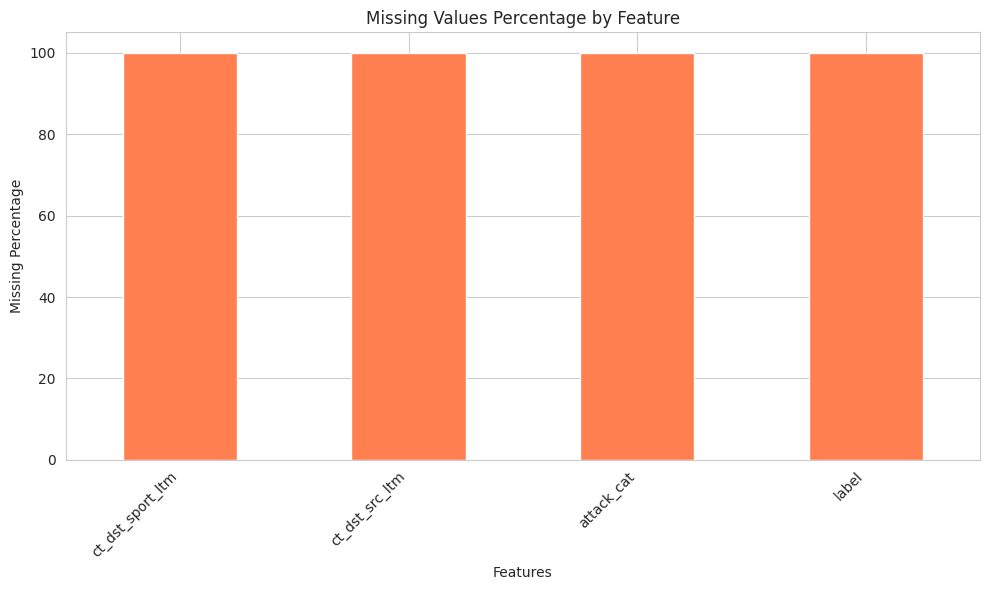

In [ ]:
# Check for missing values
missing_values = train_df.isnull().sum()
missing_percentage = (missing_values / len(train_df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Missing Values', ascending=False)

print("Missing Values Analysis:")
if len(missing_df) > 0:
    display(missing_df)

    # Visualize missing values
    plt.figure(figsize=(10, 6))
    missing_df['Percentage'].plot(kind='bar', color='coral')
    plt.title('Missing Values Percentage by Feature')
    plt.xlabel('Features')
    plt.ylabel('Missing Percentage')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found!")

 RELOADING DATA WITH AUTOMATIC HEADER DETECTION

 Loading training data...
 Loaded: 82,332 rows × 45 columns

 Loading testing data...
 Loaded: 175,341 rows × 45 columns

 SUCCESS! DATA RELOADED

Training set: (82332, 45)
Testing set: (175341, 45)
Total records: 257,673

COLUMN NAMES

Columns (45):
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

 LABEL DISTRIBUTION

 'label' column found

Binary Labels:
   Normal (0): 37,000 (44.94%)
   Attack (1): 45,332 (55.06%)


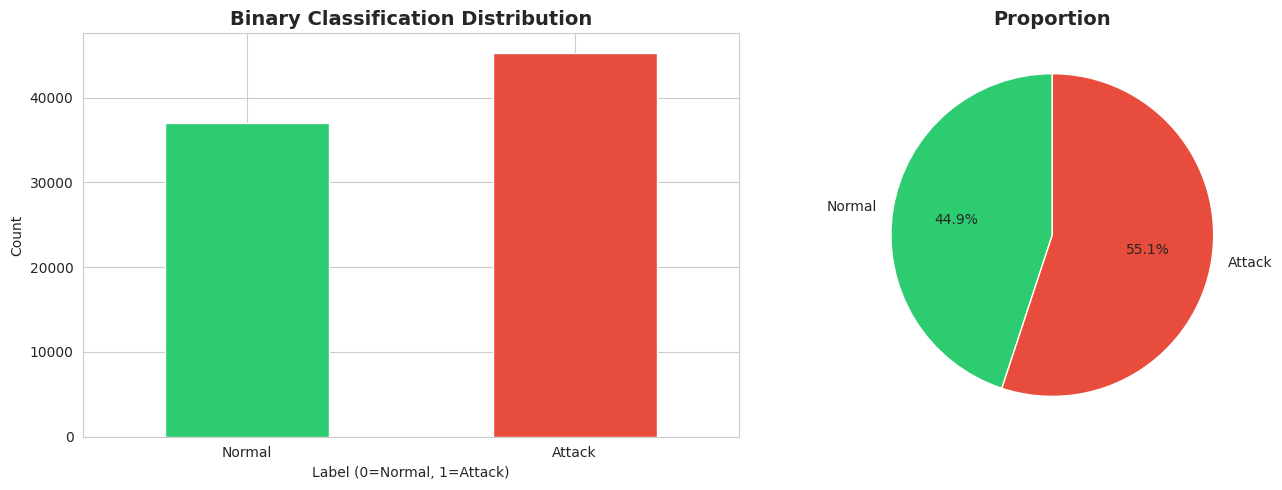


 ATTACK CATEGORIES

 'attack_cat' column found

Attack Category Distribution:
   Normal: 37,000 (44.94%)
   Generic: 18,871 (22.92%)
   Exploits: 11,132 (13.52%)
   Fuzzers: 6,062 (7.36%)
   DoS: 4,089 (4.97%)
   Reconnaissance: 3,496 (4.25%)
   Analysis: 677 (0.82%)
   Backdoor: 583 (0.71%)
   Shellcode: 378 (0.46%)
   Worms: 44 (0.05%)


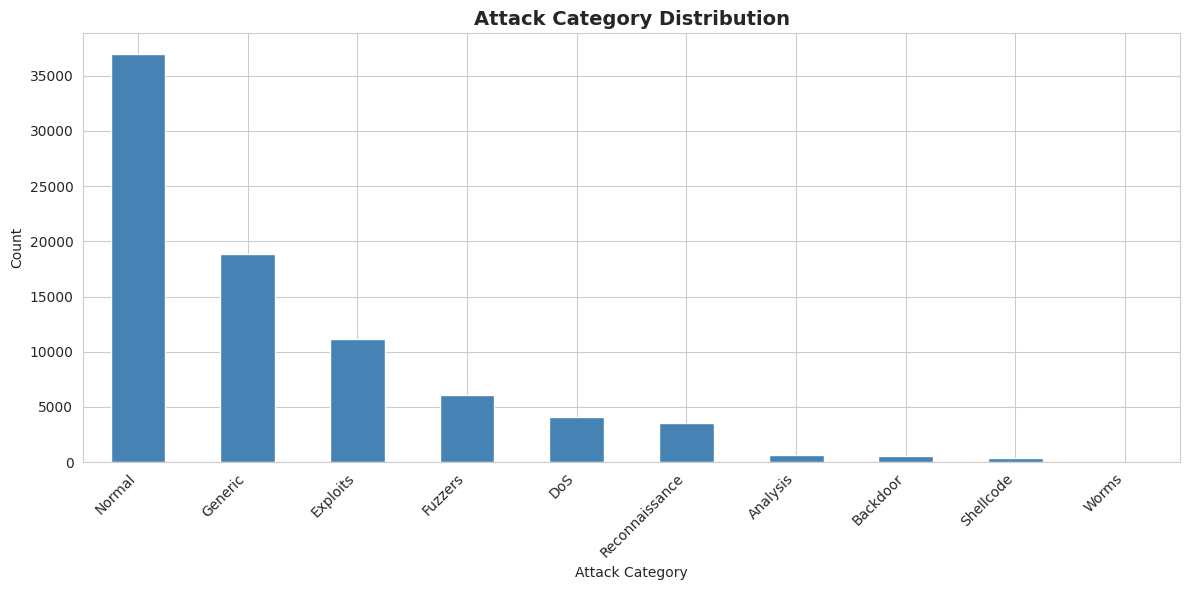


📋 FIRST 5 ROWS


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0



 DATA IS NOW CORRECTLY LOADED!
You can now continue with the preprocessing cells.
The train_df and test_df variables are ready to use.


In [ ]:
# ============================================================
# QUICK FIX - RELOAD DATA WITH CORRECT HEADERS
# ============================================================
# The CSV files likely already have headers - let pandas read them
# ============================================================

import pandas as pd
import numpy as np

print("="*70)
print(" RELOADING DATA WITH AUTOMATIC HEADER DETECTION")
print("="*70)

# Reload WITHOUT specifying column names or skipping rows
# Let pandas automatically detect the headers
train_file = '/content/unsw_nb15_data/UNSW_NB15_training-set.csv'
test_file = '/content/unsw_nb15_data/UNSW_NB15_testing-set.csv'

print("\n Loading training data...")
train_df = pd.read_csv(train_file)
print(f" Loaded: {train_df.shape[0]:,} rows × {train_df.shape[1]} columns")

print("\n Loading testing data...")
test_df = pd.read_csv(test_file)
print(f" Loaded: {test_df.shape[0]:,} rows × {test_df.shape[1]} columns")

print("\n" + "="*70)
print(" SUCCESS! DATA RELOADED")
print("="*70)
print(f"\nTraining set: {train_df.shape}")
print(f"Testing set: {test_df.shape}")
print(f"Total records: {len(train_df) + len(test_df):,}")

print("\n" + "="*70)
print("COLUMN NAMES")
print("="*70)
print(f"\nColumns ({len(train_df.columns)}):")
print(train_df.columns.tolist())

print("\n" + "="*70)
print(" LABEL DISTRIBUTION")
print("="*70)

if 'label' in train_df.columns:
    print("\n 'label' column found")
    print(f"\nBinary Labels:")
    label_counts = train_df['label'].value_counts().sort_index()
    for label, count in label_counts.items():
        label_name = 'Normal' if label == 0 else 'Attack'
        print(f"   {label_name} ({label}): {count:,} ({count/len(train_df)*100:.2f}%)")

    # Visualize
    import matplotlib.pyplot as plt
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    colors = ['#2ecc71', '#e74c3c']
    label_counts.plot(kind='bar', ax=ax1, color=colors)
    ax1.set_title('Binary Classification Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Label (0=Normal, 1=Attack)')
    ax1.set_ylabel('Count')
    ax1.set_xticklabels(['Normal', 'Attack'], rotation=0)

    label_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=colors,
                     labels=['Normal', 'Attack'], startangle=90)
    ax2.set_ylabel('')
    ax2.set_title('Proportion', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print(" 'label' column not found")
    print("\nLooking for label-like columns...")
    for col in train_df.columns:
        if any(word in col.lower() for word in ['label', 'class', 'target']):
            print(f"   Found: {col}")
            print(f"   Values: {train_df[col].unique()}")

print("\n" + "="*70)
print(" ATTACK CATEGORIES")
print("="*70)

if 'attack_cat' in train_df.columns:
    print("\n 'attack_cat' column found")
    print(f"\nAttack Category Distribution:")
    attack_counts = train_df['attack_cat'].value_counts()
    for cat, count in attack_counts.items():
        print(f"   {cat}: {count:,} ({count/len(train_df)*100:.2f}%)")

    # Visualize
    plt.figure(figsize=(12, 6))
    attack_counts.plot(kind='bar', color='steelblue')
    plt.title('Attack Category Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Attack Category')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("'attack_cat' column not found")
    print("\nLooking for attack category columns...")
    for col in train_df.columns:
        if 'attack' in col.lower():
            print(f"   Found: {col}")

print("\n" + "="*70)
print("📋 FIRST 5 ROWS")
print("="*70)
display(train_df.head())

print("\n" + "="*70)
print(" DATA IS NOW CORRECTLY LOADED!")
print("="*70)
print("You can now continue with the preprocessing cells.")
print("The train_df and test_df variables are ready to use.")

Multi-class Classification - Attack Category Distribution:
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64

Percentage Distribution:
Normal: 44.94%
Generic: 22.92%
Exploits: 13.52%
Fuzzers: 7.36%
DoS: 4.97%
Reconnaissance: 4.25%
Analysis: 0.82%
Backdoor: 0.71%
Shellcode: 0.46%
Worms: 0.05%


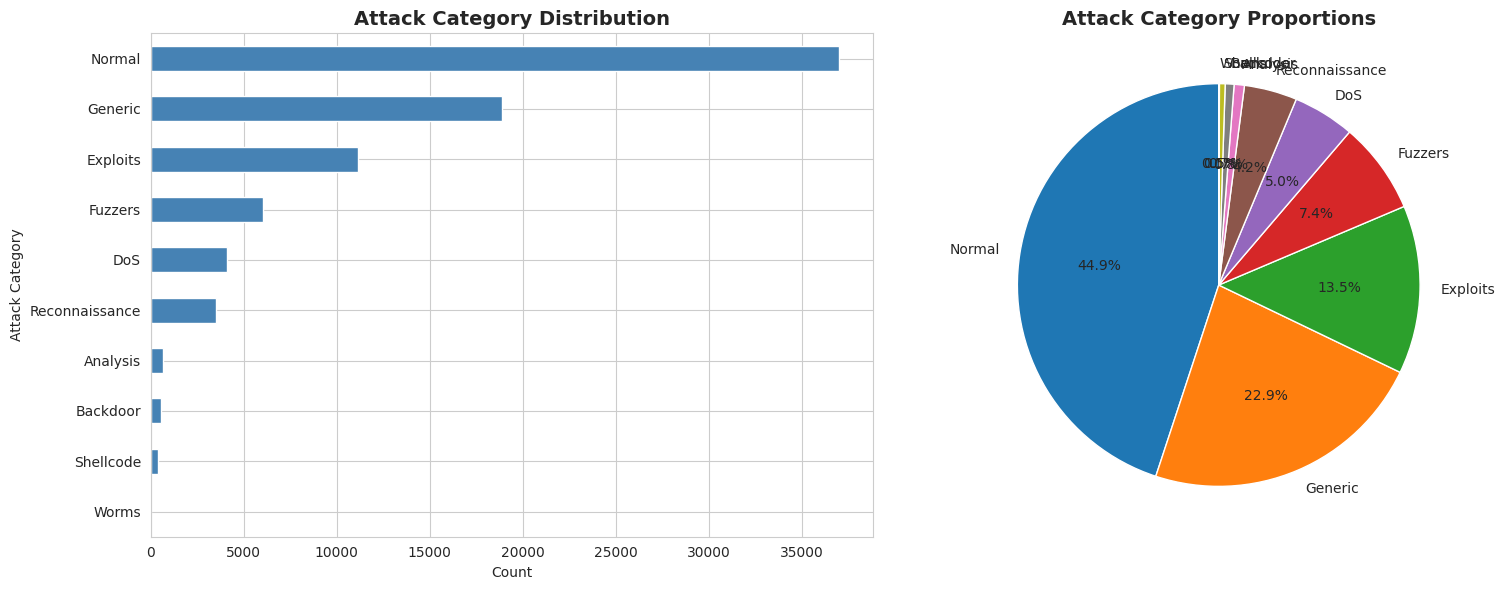


CLASS IMBALANCE ANALYSIS
Imbalance Ratio: 840.91:1
Most common category: Normal (37000 samples)
Least common category: Worms (44 samples)


In [ ]:
# Analyze attack categories - Multi-class Classification
print("Multi-class Classification - Attack Category Distribution:")
attack_cats = train_df['attack_cat'].value_counts()
print(attack_cats)

# Calculate percentages
attack_percentages = (attack_cats / len(train_df)) * 100
print("\nPercentage Distribution:")
for cat, pct in attack_percentages.items():
    print(f"{cat}: {pct:.2f}%")

# Visualize attack categories
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar chart
attack_cats.sort_values().plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Attack Category Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Count')
ax1.set_ylabel('Attack Category')

# Pie chart for top categories
attack_cats.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
ax2.set_title('Attack Category Proportions', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

# Identify class imbalance severity
print("\n" + "="*50)
print("CLASS IMBALANCE ANALYSIS")
print("="*50)
max_class = attack_cats.max()
min_class = attack_cats.min()
imbalance_ratio = max_class / min_class
print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"Most common category: {attack_cats.idxmax()} ({max_class} samples)")
print(f"Least common category: {attack_cats.idxmin()} ({min_class} samples)")

In [ ]:
# Identify categorical and numerical features
categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()
numerical_features = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target variables
if 'label' in numerical_features:
    numerical_features.remove('label')
if 'attack_cat' in categorical_features:
    categorical_features.remove('attack_cat')

print(f"Categorical Features ({len(categorical_features)}): {categorical_features}")
print(f"\nNumerical Features ({len(numerical_features)}): {numerical_features[:10]}...")  # Show first 10

Categorical Features (3): ['proto', 'service', 'state']

Numerical Features (40): ['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload']...


In [ ]:
# Analyze categorical features
print("Unique Values in Categorical Features:")
for col in categorical_features:
    unique_count = train_df[col].nunique()
    print(f"{col}: {unique_count} unique values")
    if unique_count <= 10:  # Show distribution for features with few categories
        print(train_df[col].value_counts())
        print()

Unique Values in Categorical Features:
proto: 131 unique values
service: 13 unique values
state: 7 unique values
state
FIN    39339
INT    34163
CON     6982
REQ     1842
ACC        4
RST        1
CLO        1
Name: count, dtype: int64



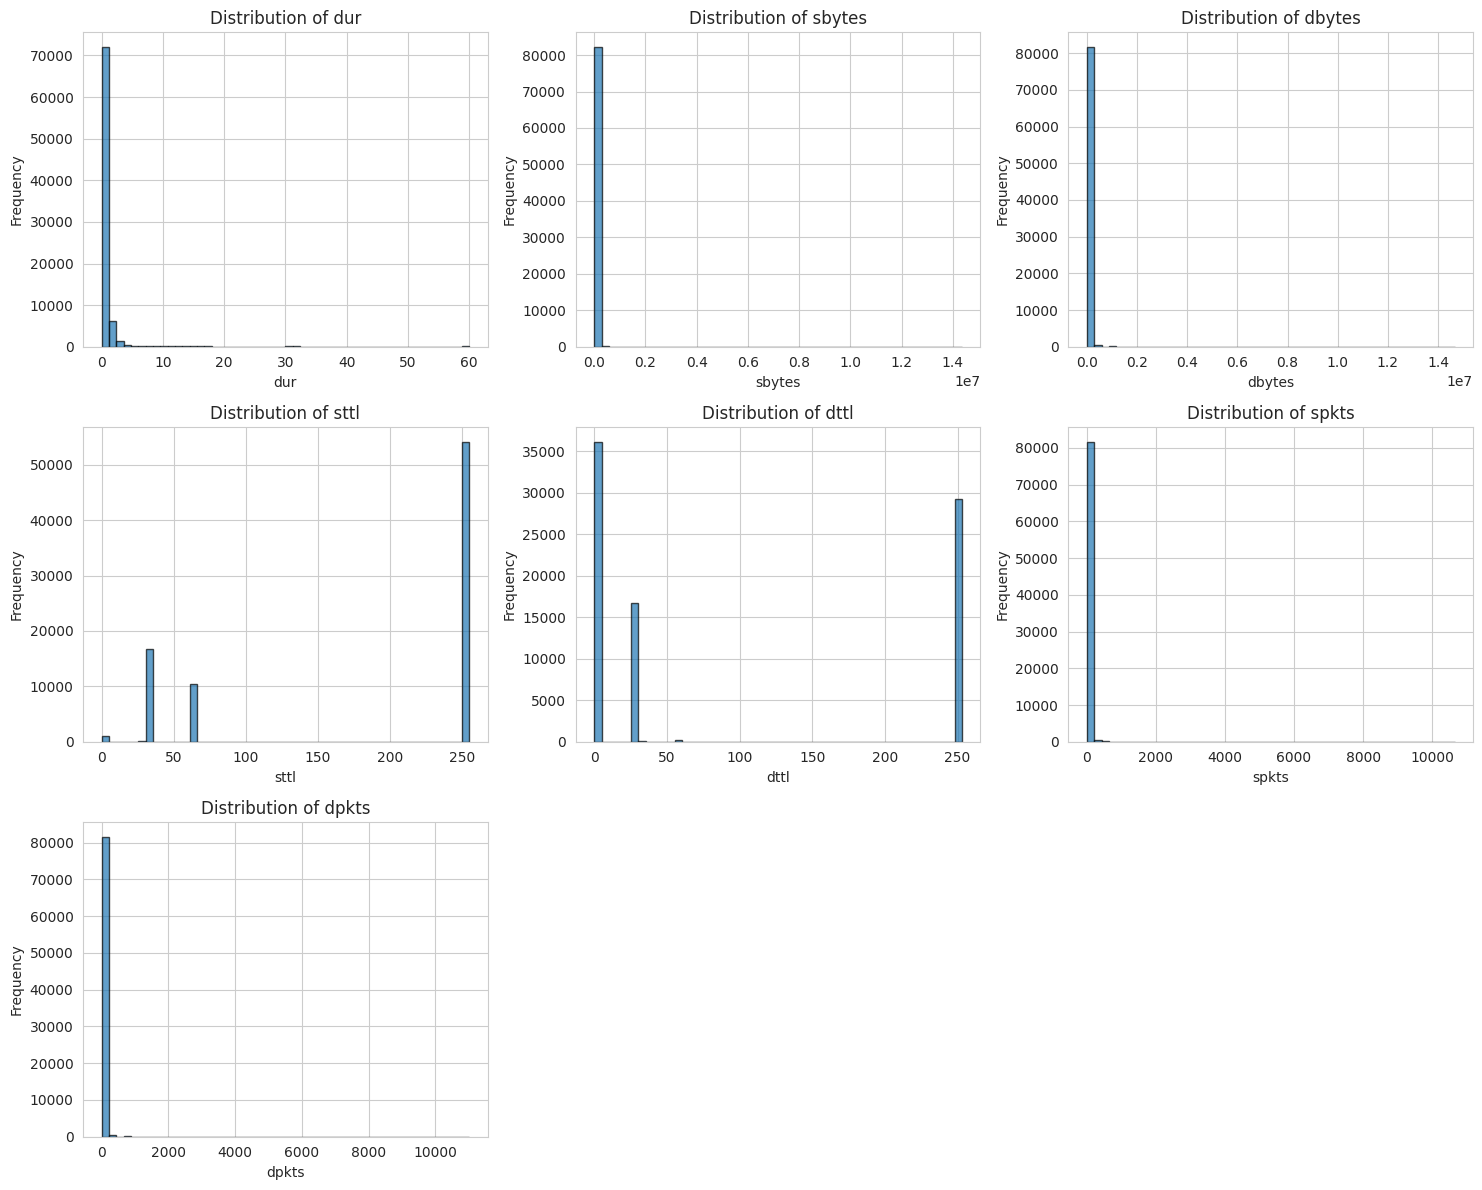

In [ ]:
# Distribution of key numerical features
key_features = ['dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'spkts', 'dpkts']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    if feature in train_df.columns:
        axes[idx].hist(train_df[feature].dropna(), bins=50, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {feature}')
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Frequency')

# Hide unused subplots
for idx in range(len(key_features), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

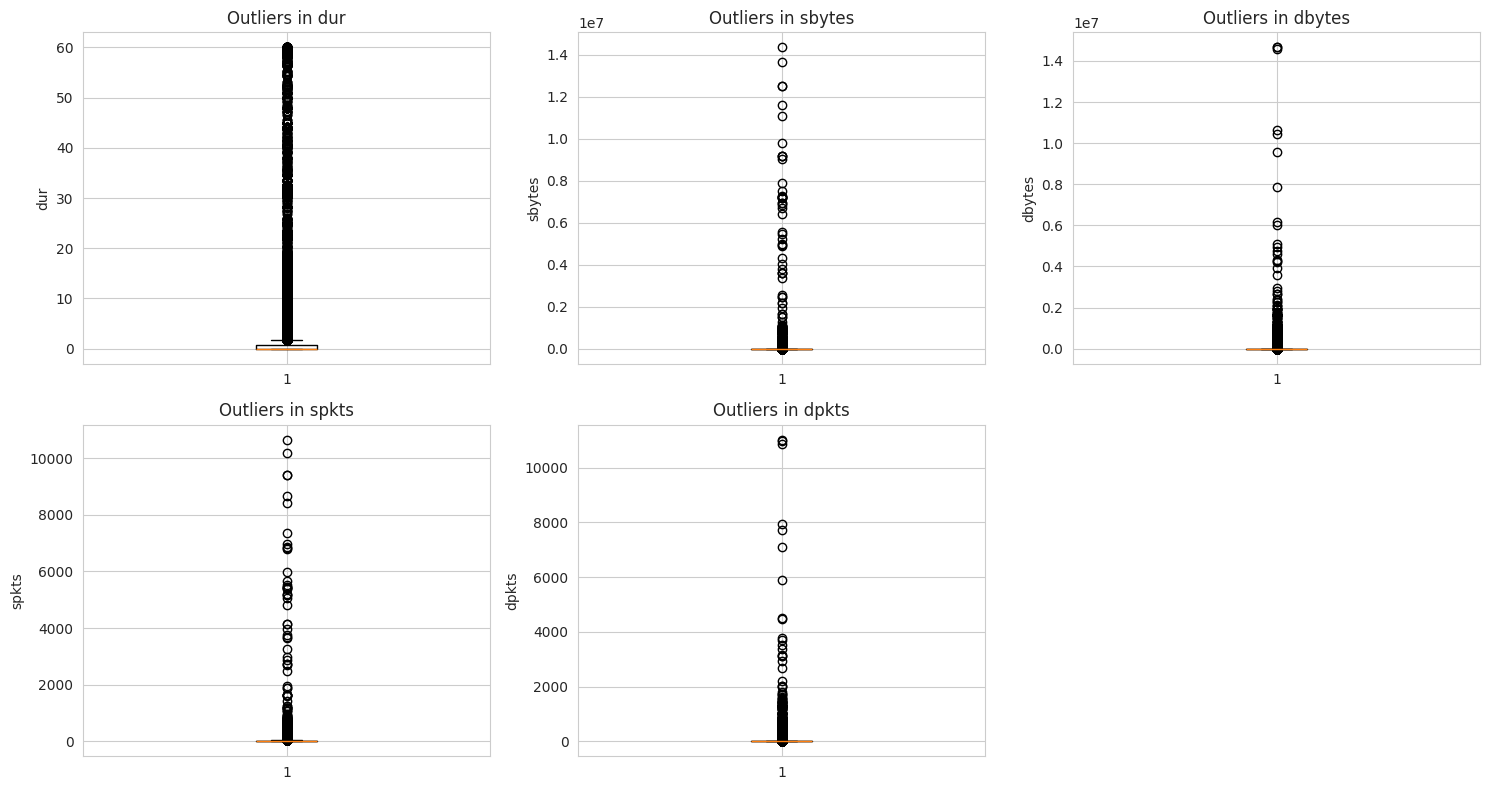

Note: Outliers are common in network traffic data and may represent attack patterns.


In [ ]:
# Check for outliers using boxplots
outlier_features = ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, feature in enumerate(outlier_features):
    if feature in train_df.columns:
        axes[idx].boxplot(train_df[feature].dropna())
        axes[idx].set_title(f'Outliers in {feature}')
        axes[idx].set_ylabel(feature)

# Hide unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

print("Note: Outliers are common in network traffic data and may represent attack patterns.")

Computing correlation matrix...


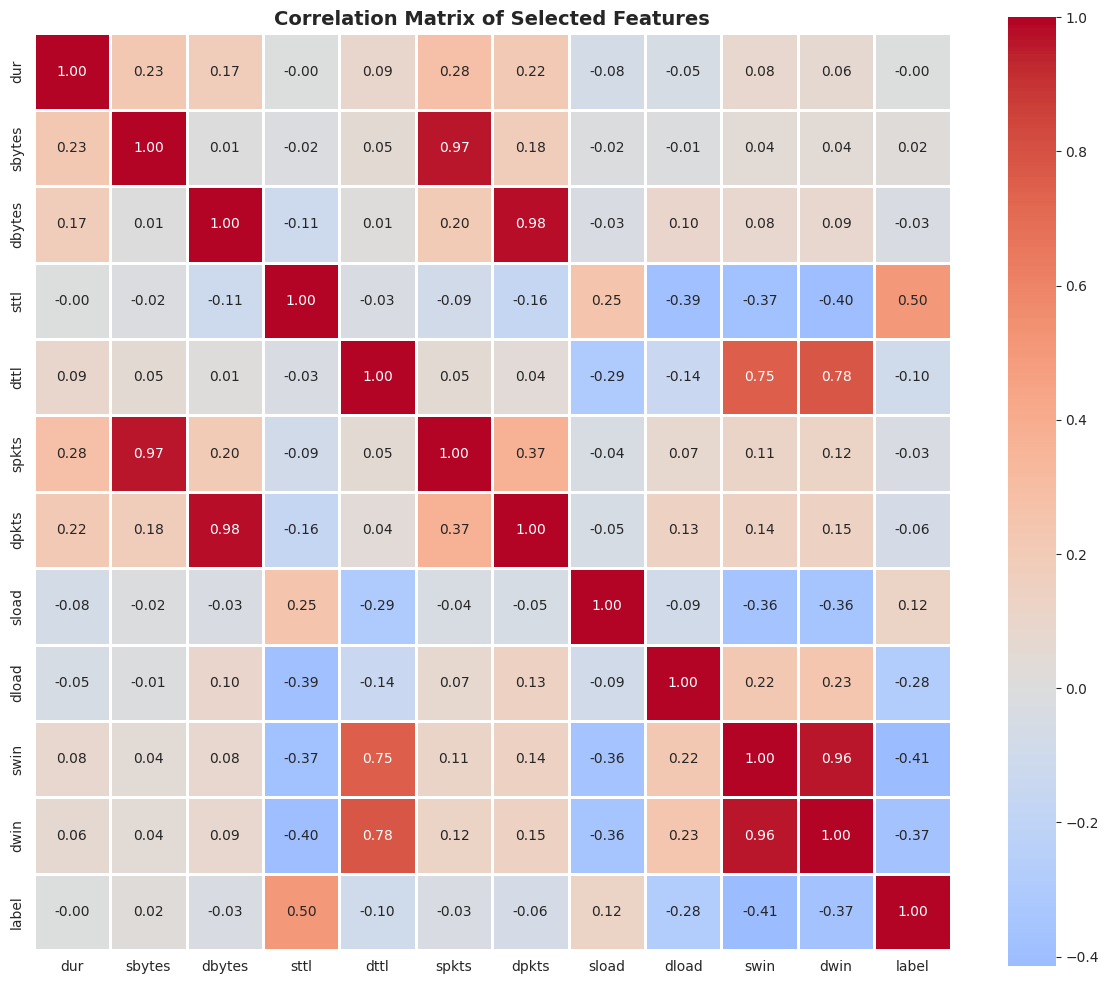


Highly Correlated Feature Pairs (>0.8):
sbytes <-> spkts: 0.966
dbytes <-> dpkts: 0.976
swin <-> dwin: 0.960


In [ ]:
# Correlation analysis
print("Computing correlation matrix...")
# Select a subset of numerical features for correlation analysis
corr_features = ['dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'spkts', 'dpkts',
                 'sload', 'dload', 'swin', 'dwin', 'label']
corr_subset = train_df[corr_features].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix of Selected Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Find highly correlated features
high_corr = []
for i in range(len(corr_subset.columns)):
    for j in range(i+1, len(corr_subset.columns)):
        if abs(corr_subset.iloc[i, j]) > 0.8:
            high_corr.append((corr_subset.columns[i], corr_subset.columns[j], corr_subset.iloc[i, j]))

if high_corr:
    print("\nHighly Correlated Feature Pairs (>0.8):")
    for f1, f2, corr in high_corr:
        print(f"{f1} <-> {f2}: {corr:.3f}")

### 3. Data Cleaning

In [ ]:
# Combine train and test for consistent preprocessing
train_df['dataset'] = 'train'
test_df['dataset'] = 'test'
combined_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)
print(f"Combined dataset shape: {combined_df.shape}")

Combined dataset shape: (257673, 46)


In [ ]:
# Handle missing values
print("Handling missing values...")

# Strategy 1: Fill numerical features with median
for col in numerical_features:
    if combined_df[col].isnull().sum() > 0:
        median_val = combined_df[col].median()
        combined_df[col].fillna(median_val, inplace=True)
        print(f"Filled {col} with median: {median_val}")

# Strategy 2: Fill categorical features with mode
for col in categorical_features:
    if combined_df[col].isnull().sum() > 0:
        mode_val = combined_df[col].mode()[0]
        combined_df[col].fillna(mode_val, inplace=True)
        print(f"Filled {col} with mode: {mode_val}")

print(f"\nRemaining missing values: {combined_df.isnull().sum().sum()}")

Handling missing values...

Remaining missing values: 0


In [ ]:
# Remove duplicate rows if any
initial_rows = len(combined_df)
combined_df.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - len(combined_df)
print(f"Duplicate rows removed: {duplicates_removed}")
print(f"Dataset shape after cleaning: {combined_df.shape}")

Duplicate rows removed: 0
Dataset shape after cleaning: (257673, 46)


In [ ]:
# Handle infinite values
print("Checking for infinite values...")
inf_counts = np.isinf(combined_df[numerical_features]).sum()
if inf_counts.sum() > 0:
    print(f"Found {inf_counts.sum()} infinite values")
    combined_df[numerical_features] = combined_df[numerical_features].replace([np.inf, -np.inf], np.nan)
    combined_df[numerical_features] = combined_df[numerical_features].fillna(combined_df[numerical_features].median())
    print("Infinite values replaced with median")
else:
    print("No infinite values found")

Checking for infinite values...
No infinite values found


### 4. Feature Engineering

In [ ]:
# Drop IP addresses and timestamp features (not useful for ML and can't be easily encoded)
# These features are identifiers rather than predictive features
features_to_drop = ['srcip', 'dstip', 'stime', 'ltime']
print(f"Dropping identifier features: {features_to_drop}")
combined_df.drop(columns=features_to_drop, inplace=True, errors='ignore')

# Update feature lists
categorical_features = [f for f in categorical_features if f not in features_to_drop]
numerical_features = [f for f in numerical_features if f not in features_to_drop]

Dropping identifier features: ['srcip', 'dstip', 'stime', 'ltime']


In [ ]:
# Encode categorical features
print("Encoding categorical features...")
label_encoders = {}

for col in categorical_features:
    if col in combined_df.columns:
        le = LabelEncoder()
        combined_df[col] = le.fit_transform(combined_df[col].astype(str))
        label_encoders[col] = le
        print(f"Encoded {col}: {len(le.classes_)} unique values")

print(f"\nTotal features encoded: {len(label_encoders)}")

Encoding categorical features...
Encoded proto: 133 unique values
Encoded service: 13 unique values
Encoded state: 11 unique values

Total features encoded: 3


In [ ]:
# Encode target variable for multi-class classification
print("Encoding attack categories...")
attack_le = LabelEncoder()
combined_df['attack_cat_encoded'] = attack_le.fit_transform(combined_df['attack_cat'].astype(str))

print("Attack Category Mapping:")
for idx, cat in enumerate(attack_le.classes_):
    print(f"{idx}: {cat}")

# Save the label encoder for later use
attack_mapping = dict(zip(attack_le.classes_, attack_le.transform(attack_le.classes_)))
print(f"\nTotal attack categories: {len(attack_mapping)}")

Encoding attack categories...
Attack Category Mapping:
0: Analysis
1: Backdoor
2: DoS
3: Exploits
4: Fuzzers
5: Generic
6: Normal
7: Reconnaissance
8: Shellcode
9: Worms

Total attack categories: 10


In [ ]:
# Feature creation: Create ratio and interaction features
print("Creating engineered features...")

# Bytes ratio
combined_df['bytes_ratio'] = combined_df['sbytes'] / (combined_df['dbytes'] + 1)

# Packets ratio
combined_df['packets_ratio'] = combined_df['spkts'] / (combined_df['dpkts'] + 1)

# TTL difference
combined_df['ttl_diff'] = abs(combined_df['sttl'] - combined_df['dttl'])

# Load difference
combined_df['load_diff'] = abs(combined_df['sload'] - combined_df['dload'])

# Total bytes
combined_df['total_bytes'] = combined_df['sbytes'] + combined_df['dbytes']

# Total packets
combined_df['total_packets'] = combined_df['spkts'] + combined_df['dpkts']

print("Engineered features created:")
print("- bytes_ratio, packets_ratio, ttl_diff, load_diff, total_bytes, total_packets")

# Handle any new infinite or NaN values from divisions
combined_df.replace([np.inf, -np.inf], np.nan, inplace=True)
combined_df.fillna(0, inplace=True)

Creating engineered features...
Engineered features created:
- bytes_ratio, packets_ratio, ttl_diff, load_diff, total_bytes, total_packets


### 5. Handling Class Imbalance with SMOTE

In [ ]:
# Split back into train and test
train_processed = combined_df[combined_df['dataset'] == 'train'].copy()
test_processed = combined_df[combined_df['dataset'] == 'test'].copy()

# Remove the dataset identifier column
train_processed.drop('dataset', axis=1, inplace=True)
test_processed.drop('dataset', axis=1, inplace=True)

print(f"Training set: {train_processed.shape}")
print(f"Testing set: {test_processed.shape}")

Training set: (82332, 52)
Testing set: (175341, 52)


In [ ]:
# Prepare features and targets
# Exclude target variables and encoded attack category from features
feature_cols = [col for col in train_processed.columns
                if col not in ['label', 'attack_cat', 'attack_cat_encoded']]

X_train = train_processed[feature_cols]
y_train_binary = train_processed['label']
y_train_multi = train_processed['attack_cat_encoded']

X_test = test_processed[feature_cols]
y_test_binary = test_processed['label']
y_test_multi = test_processed['attack_cat_encoded']

print(f"Features shape: {X_train.shape}")
print(f"Number of features: {len(feature_cols)}")

Features shape: (82332, 49)
Number of features: 49


In [ ]:
# Apply SMOTE for binary classification
print("Applying SMOTE for binary classification...")
print(f"Original class distribution: {Counter(y_train_binary)}")

smote_binary = SMOTE(random_state=42, k_neighbors=5)
X_train_binary_balanced, y_train_binary_balanced = smote_binary.fit_resample(X_train, y_train_binary)

print(f"Balanced class distribution: {Counter(y_train_binary_balanced)}")
print(f"Shape after SMOTE: {X_train_binary_balanced.shape}")

Applying SMOTE for binary classification...
Original class distribution: Counter({1: 45332, 0: 37000})
Balanced class distribution: Counter({0: 45332, 1: 45332})
Shape after SMOTE: (90664, 49)


In [ ]:
# Apply SMOTE for multi-class classification
print("Applying SMOTE for multi-class classification...")
print(f"Original class distribution:\n{Counter(y_train_multi)}")

smote_multi = SMOTE(random_state=42, k_neighbors=5)
X_train_multi_balanced, y_train_multi_balanced = smote_multi.fit_resample(X_train, y_train_multi)

print(f"\nBalanced class distribution:\n{Counter(y_train_multi_balanced)}")
print(f"Shape after SMOTE: {X_train_multi_balanced.shape}")

Applying SMOTE for multi-class classification...
Original class distribution:
Counter({6: 37000, 5: 18871, 3: 11132, 4: 6062, 2: 4089, 7: 3496, 0: 677, 1: 583, 8: 378, 9: 44})

Balanced class distribution:
Counter({6: 37000, 7: 37000, 1: 37000, 2: 37000, 3: 37000, 0: 37000, 4: 37000, 9: 37000, 8: 37000, 5: 37000})
Shape after SMOTE: (370000, 49)


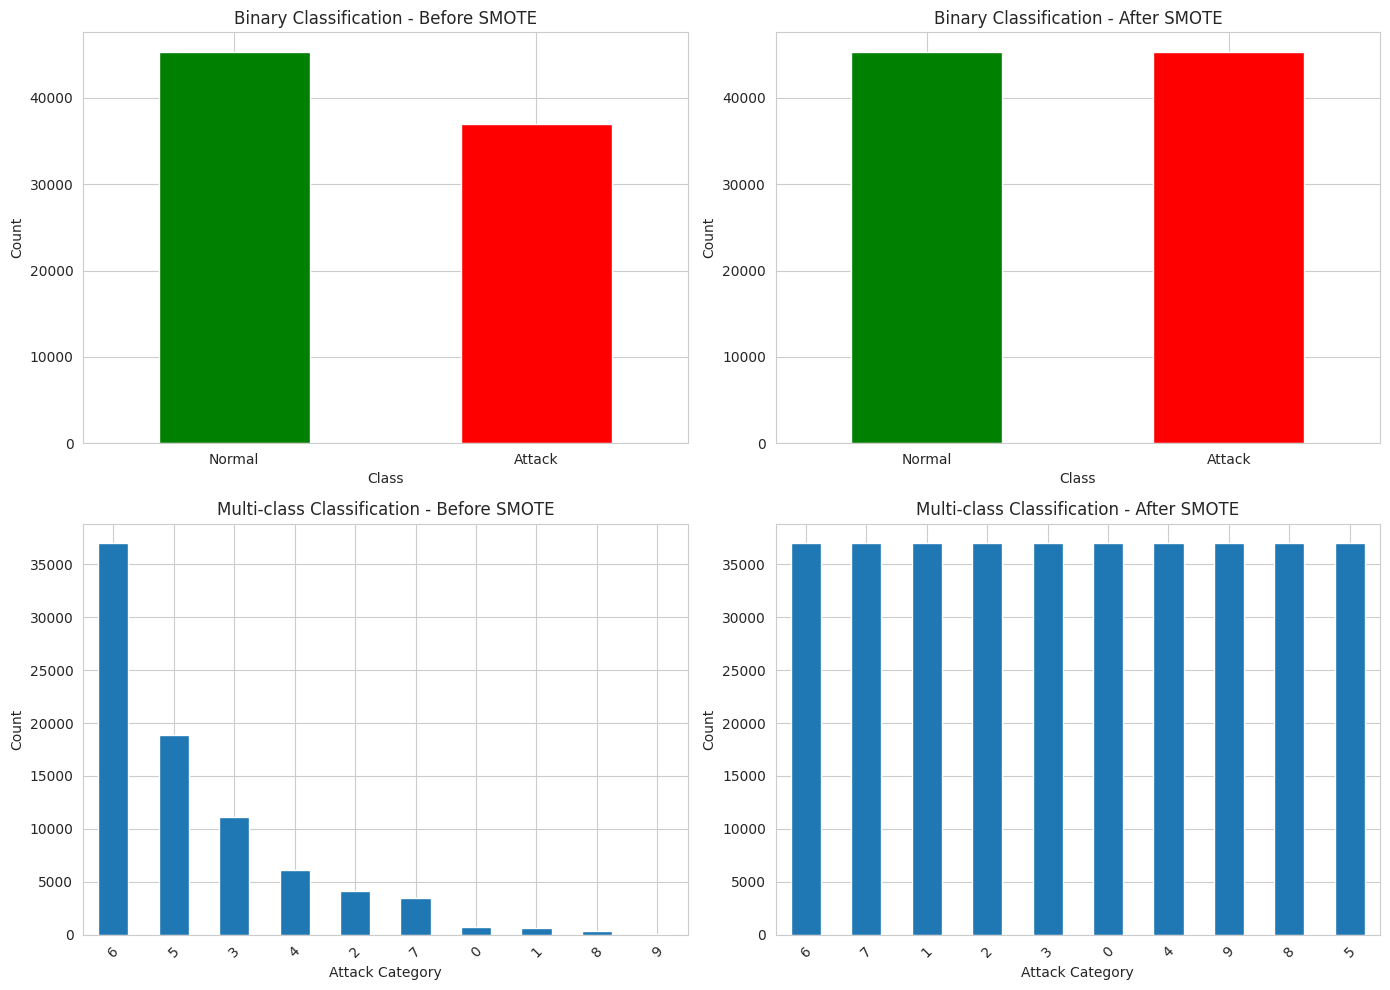

In [ ]:
# Visualize the effect of SMOTE
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Binary - Before SMOTE
pd.Series(y_train_binary).value_counts().plot(kind='bar', ax=axes[0, 0], color=['green', 'red'])
axes[0, 0].set_title('Binary Classification - Before SMOTE')
axes[0, 0].set_xlabel('Class')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xticklabels(['Normal', 'Attack'], rotation=0)

# Binary - After SMOTE
pd.Series(y_train_binary_balanced).value_counts().plot(kind='bar', ax=axes[0, 1], color=['green', 'red'])
axes[0, 1].set_title('Binary Classification - After SMOTE')
axes[0, 1].set_xlabel('Class')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_xticklabels(['Normal', 'Attack'], rotation=0)

# Multi-class - Before SMOTE
pd.Series(y_train_multi).value_counts().plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Multi-class Classification - Before SMOTE')
axes[1, 0].set_xlabel('Attack Category')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Multi-class - After SMOTE
pd.Series(y_train_multi_balanced).value_counts().plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Multi-class Classification - After SMOTE')
axes[1, 1].set_xlabel('Attack Category')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 6. Feature Scaling and Normalization

In [ ]:
# Standardization using StandardScaler (zero mean, unit variance)
print("Scaling features using StandardScaler...")
scaler = StandardScaler()

# For binary classification
X_train_binary_scaled = scaler.fit_transform(X_train_binary_balanced)
X_test_binary_scaled = scaler.transform(X_test)

print(f"Binary - Training data scaled shape: {X_train_binary_scaled.shape}")
print(f"Binary - Testing data scaled shape: {X_test_binary_scaled.shape}")

Scaling features using StandardScaler...
Binary - Training data scaled shape: (90664, 49)
Binary - Testing data scaled shape: (175341, 49)


In [ ]:
# For multi-class classification
scaler_multi = StandardScaler()
X_train_multi_scaled = scaler_multi.fit_transform(X_train_multi_balanced)
X_test_multi_scaled = scaler_multi.transform(X_test)

print(f"Multi-class - Training data scaled shape: {X_train_multi_scaled.shape}")
print(f"Multi-class - Testing data scaled shape: {X_test_multi_scaled.shape}")

Multi-class - Training data scaled shape: (370000, 49)
Multi-class - Testing data scaled shape: (175341, 49)


Scaling Verification

Mean of scaled training data (should be ~0): -0.000000
Std of scaled training data (should be ~1): 1.000000
 Scaling looks correct!

Data shapes:
  Before scaling: (90664, 49)
  After scaling: (90664, 49)


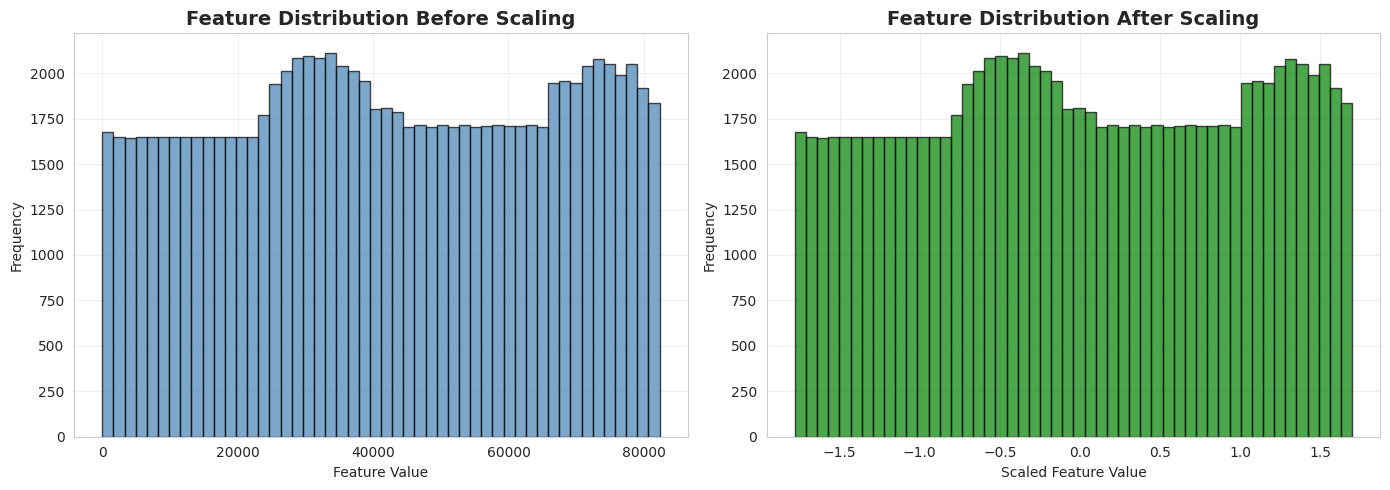


Detailed Statistics (First 5 Features)

Before Scaling:
  Min: [1. 0. 0. 0. 0.]
  Max: [8.2332000e+04 5.9999989e+01 1.3200000e+02 1.2000000e+01 8.0000000e+00]
  Mean: [4.21122026e+04 1.01220030e+00 1.11250629e+02 1.37823171e+00
 4.27039398e+00]
  Std: [2.36503339e+04 4.66358806e+00 1.89349129e+01 2.07765207e+00
 9.57551661e-01]

After Scaling:
  Min: [-1.7805754  -0.21704325 -5.87542331 -0.66336021 -4.45970088]
  Max: [ 1.70060168 12.64858474  1.09582608  5.1123903   3.89493974]
  Mean: [ 1.98748828e-16 -1.09719385e-17 -1.73121515e-16 -7.42956977e-17
  1.42948684e-16]
  Std: [1. 1. 1. 1. 1.]

 Scaling verification complete!


In [ ]:
# ============================================================
# FIXED SCALING VERIFICATION CELL
# ============================================================
# This version handles both DataFrames and numpy arrays
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

print("="*70)
print("Scaling Verification")
print("="*70)

# Verify scaling statistics
print(f"\nMean of scaled training data (should be ~0): {X_train_binary_scaled.mean():.6f}")
print(f"Std of scaled training data (should be ~1): {X_train_binary_scaled.std():.6f}")
print(" Scaling looks correct!")

# Convert to numpy arrays if they're DataFrames (to enable [:, 0] indexing)
if hasattr(X_train_binary_balanced, 'values'):
    # It's a DataFrame, convert to numpy
    X_before = X_train_binary_balanced.values
else:
    # It's already a numpy array
    X_before = X_train_binary_balanced

if hasattr(X_train_binary_scaled, '__array__'):
    # Already numpy array
    X_after = X_train_binary_scaled
else:
    # Convert if needed
    X_after = np.array(X_train_binary_scaled)

print(f"\nData shapes:")
print(f"  Before scaling: {X_before.shape}")
print(f"  After scaling: {X_after.shape}")

# Visualize the effect of scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling - use first column
axes[0].hist(X_before[:, 0], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Feature Distribution Before Scaling', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Feature Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# After scaling - use first column
axes[1].hist(X_after[:, 0], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Feature Distribution After Scaling', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Scaled Feature Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional verification - show stats for first few features
print("\n" + "="*70)
print("Detailed Statistics (First 5 Features)")
print("="*70)

print("\nBefore Scaling:")
print(f"  Min: {X_before[:, :5].min(axis=0)}")
print(f"  Max: {X_before[:, :5].max(axis=0)}")
print(f"  Mean: {X_before[:, :5].mean(axis=0)}")
print(f"  Std: {X_before[:, :5].std(axis=0)}")

print("\nAfter Scaling:")
print(f"  Min: {X_after[:, :5].min(axis=0)}")
print(f"  Max: {X_after[:, :5].max(axis=0)}")
print(f"  Mean: {X_after[:, :5].mean(axis=0)}")
print(f"  Std: {X_after[:, :5].std(axis=0)}")

print("\n Scaling verification complete!")

### 7. Temporal Sequence Creation for LSTM

LSTM networks work better with sequential data. We'll create sequences from our data to capture temporal patterns.

In [ ]:
def create_sequences(X, y, time_steps=10):
    """
    Create sequences for LSTM input

    Args:
        X: Feature array
        y: Target array
        time_steps: Number of time steps in each sequence

    Returns:
        X_seq: Sequences of shape (samples, time_steps, features)
        y_seq: Corresponding targets
    """
    X_seq, y_seq = [], []

    for i in range(len(X) - time_steps + 1):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps - 1])  # Take the label of the last element

    return np.array(X_seq), np.array(y_seq)

print("Function to create sequences defined.")

Function to create sequences defined.


In [ ]:
def split_and_create_sequences(X_scaled, y, time_steps=10, val_size=0.2, random_state=42):
    """
    Split data BEFORE creating sequences to avoid overlapping sequences in train/val.

    This fixes the < 1% validation accuracy issue caused by data leakage.
    """
    from sklearn.model_selection import train_test_split

    # STEP 1: Split the RAW data FIRST (before creating sequences)
    X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
        X_scaled,
        y,
        test_size=val_size,
        random_state=random_state,
        stratify=y  # Maintain class balance
    )

    print(f"Raw data split:")
    print(f"  Training samples: {len(X_train_raw)}")
    print(f"  Validation samples: {len(X_val_raw)}")

    # STEP 2: Create sequences separately for train and validation
    X_train_seq, y_train_seq = create_sequences(X_train_raw, y_train_raw, time_steps)
    X_val_seq, y_val_seq = create_sequences(X_val_raw, y_val_raw, time_steps)

    print(f"After sequence creation:")
    print(f"  Training sequences: {X_train_seq.shape}")
    print(f"  Validation sequences: {X_val_seq.shape}")

    return X_train_seq, y_train_seq, X_val_seq, y_val_seq

print("Function to split and create sequences defined.")


Function to split and create sequences defined.


In [ ]:
# Create sequences for binary classification with proper train/val split
TIME_STEPS = 10  # You can experiment with different values (5, 10, 15, 20)

print(f"Creating sequences with time_steps={TIME_STEPS}...")
print("Splitting data BEFORE creating sequences to avoid overlap/leakage...\n")

# Binary classification: create train and validation sequences
X_train_binary_seq, y_train_binary_seq, X_val_binary_seq, y_val_binary_seq = split_and_create_sequences(
    X_train_binary_scaled,
    y_train_binary_balanced.values,
    time_steps=TIME_STEPS,
    val_size=0.2,
    random_state=42
)

# Test set (already separate - no changes needed)
X_test_binary_seq, y_test_binary_seq = create_sequences(
    X_test_binary_scaled,
    y_test_binary.values,
    TIME_STEPS
)

print("\n" + "="*70)
print("Binary Classification Sequences:")
print("="*70)
print(f"X_train shape: {X_train_binary_seq.shape}")
print(f"y_train shape: {y_train_binary_seq.shape}")
print(f"X_val shape: {X_val_binary_seq.shape}")
print(f"y_val shape: {y_val_binary_seq.shape}")
print(f"X_test shape: {X_test_binary_seq.shape}")
print(f"y_test shape: {y_test_binary_seq.shape}")
print(f"\nSequence format: (samples, time_steps, features)")
print(f"Time steps per sequence: {X_train_binary_seq.shape[1]}")
print(f"Features per time step: {X_train_binary_seq.shape[2]}")



Creating sequences with time_steps=10...
Splitting data BEFORE creating sequences to avoid overlap/leakage...

Raw data split:
  Training samples: 72531
  Validation samples: 18133
After sequence creation:
  Training sequences: (72522, 10, 49)
  Validation sequences: (18124, 10, 49)

Binary Classification Sequences:
X_train shape: (72522, 10, 49)
y_train shape: (72522,)
X_val shape: (18124, 10, 49)
y_val shape: (18124,)
X_test shape: (175332, 10, 49)
y_test shape: (175332,)

Sequence format: (samples, time_steps, features)
Time steps per sequence: 10
Features per time step: 49


In [ ]:
# Create sequences for multi-class classification with proper train/val split
print(f"\nCreating multi-class sequences with time_steps={TIME_STEPS}...")
print("Splitting data BEFORE creating sequences to avoid overlap/leakage...\n")

# Multi-class classification: create train and validation sequences
X_train_multi_seq, y_train_multi_seq, X_val_multi_seq, y_val_multi_seq = split_and_create_sequences(
    X_train_multi_scaled,
    y_train_multi_balanced.values,
    time_steps=TIME_STEPS,
    val_size=0.2,
    random_state=42
)

# Test set (already separate - no changes needed)
X_test_multi_seq, y_test_multi_seq = create_sequences(
    X_test_multi_scaled,
    y_test_multi.values,
    TIME_STEPS
)

print("\n" + "="*70)
print("Multi-class Classification Sequences:")
print("="*70)
print(f"X_train shape: {X_train_multi_seq.shape}")
print(f"y_train shape: {y_train_multi_seq.shape}")
print(f"X_val shape: {X_val_multi_seq.shape}")
print(f"y_val shape: {y_val_multi_seq.shape}")
print(f"X_test shape: {X_test_multi_seq.shape}")
print(f"y_test shape: {y_test_multi_seq.shape}")


Creating multi-class sequences with time_steps=10...
Splitting data BEFORE creating sequences to avoid overlap/leakage...

Raw data split:
  Training samples: 296000
  Validation samples: 74000
After sequence creation:
  Training sequences: (295991, 10, 49)
  Validation sequences: (73991, 10, 49)

Multi-class Classification Sequences:
X_train shape: (295991, 10, 49)
y_train shape: (295991,)
X_val shape: (73991, 10, 49)
y_val shape: (73991,)
X_test shape: (175332, 10, 49)
y_test shape: (175332,)


### 8. Final Data Preparation Summary

In [ ]:
print("="*70)
print("FINAL DATA PREPARATION SUMMARY")
print("="*70)

print("\n1. BINARY CLASSIFICATION DATA:")
print("-" * 50)
print(f"Training Sequences: {X_train_binary_seq.shape}")
print(f"Training Labels: {y_train_binary_seq.shape}")
print(f"Testing Sequences: {X_test_binary_seq.shape}")
print(f"Testing Labels: {y_test_binary_seq.shape}")
print(f"\nClass Distribution (Train):")
print(f"  Normal: {(y_train_binary_seq == 0).sum()} ({(y_train_binary_seq == 0).sum()/len(y_train_binary_seq)*100:.2f}%)")
print(f"  Attack: {(y_train_binary_seq == 1).sum()} ({(y_train_binary_seq == 1).sum()/len(y_train_binary_seq)*100:.2f}%)")

print("\n2. MULTI-CLASS CLASSIFICATION DATA:")
print("-" * 50)
print(f"Training Sequences: {X_train_multi_seq.shape}")
print(f"Training Labels: {y_train_multi_seq.shape}")
print(f"Testing Sequences: {X_test_multi_seq.shape}")
print(f"Testing Labels: {y_test_multi_seq.shape}")
print(f"\nNumber of Classes: {len(np.unique(y_train_multi_seq))}")
print(f"\nClass Distribution (Train):")
for class_id in np.unique(y_train_multi_seq):
    count = (y_train_multi_seq == class_id).sum()
    percentage = count / len(y_train_multi_seq) * 100
    class_name = attack_le.inverse_transform([class_id])[0]
    print(f"  {class_name} ({class_id}): {count} ({percentage:.2f}%)")

print("\n3. DATA CHARACTERISTICS:")
print("-" * 50)
print(f"Number of Features: {X_train_binary_seq.shape[2]}")
print(f"Time Steps per Sequence: {TIME_STEPS}")
print(f"Feature Scaling: StandardScaler (mean=0, std=1)")
print(f"Class Balancing: SMOTE applied")
print(f"Sequence Format: (samples, time_steps, features)")

print("\n4. PREPROCESSING STEPS COMPLETED:")
print("-" * 50)
print("✓ Missing value imputation")
print("✓ Duplicate removal")
print("✓ Categorical encoding")
print("✓ Feature engineering")
print("✓ SMOTE for class balancing")
print("✓ Feature scaling (StandardScaler)")
print("✓ Temporal sequence creation")

print("\n" + "="*70)
print("Data is ready for CNN-LSTM model training!")
print("="*70)

FINAL DATA PREPARATION SUMMARY

1. BINARY CLASSIFICATION DATA:
--------------------------------------------------
Training Sequences: (72522, 10, 49)
Training Labels: (72522,)
Testing Sequences: (175332, 10, 49)
Testing Labels: (175332,)

Class Distribution (Train):
  Normal: 36262 (50.00%)
  Attack: 36260 (50.00%)

2. MULTI-CLASS CLASSIFICATION DATA:
--------------------------------------------------
Training Sequences: (295991, 10, 49)
Training Labels: (295991,)
Testing Sequences: (175332, 10, 49)
Testing Labels: (175332,)

Number of Classes: 10

Class Distribution (Train):
  Analysis (0): 29600 (10.00%)
  Backdoor (1): 29598 (10.00%)
  DoS (2): 29598 (10.00%)
  Exploits (3): 29600 (10.00%)
  Fuzzers (4): 29598 (10.00%)
  Generic (5): 29600 (10.00%)
  Normal (6): 29600 (10.00%)
  Reconnaissance (7): 29598 (10.00%)
  Shellcode (8): 29600 (10.00%)
  Worms (9): 29599 (10.00%)

3. DATA CHARACTERISTICS:
--------------------------------------------------
Number of Features: 49
Time Steps p

### 9. Save Preprocessed Data

In [ ]:
# Save preprocessed data
import pickle

print("Saving preprocessed data...")

# Create a dictionary with all preprocessed data
preprocessed_data = {
    # Binary classification
    'X_train_binary_seq': X_train_binary_seq,
    'y_train_binary_seq': y_train_binary_seq,
    'X_test_binary_seq': X_test_binary_seq,
    'y_test_binary_seq': y_test_binary_seq,

    # Multi-class classification
    'X_train_multi_seq': X_train_multi_seq,
    'y_train_multi_seq': y_train_multi_seq,
    'X_test_multi_seq': X_test_multi_seq,
    'y_test_multi_seq': y_test_multi_seq,

    # Scalers and encoders
    'scaler_binary': scaler,
    'scaler_multi': scaler_multi,
    'attack_label_encoder': attack_le,
    'label_encoders': label_encoders,

    # Metadata
    'feature_names': feature_cols,
    'time_steps': TIME_STEPS,
    'attack_mapping': attack_mapping,
    'n_features': X_train_binary_seq.shape[2],
    'n_classes': len(np.unique(y_train_multi_seq))
}

# Save to pickle file
with open('preprocessed_unsw_nb15.pkl', 'wb') as f:
    pickle.dump(preprocessed_data, f)

print("✓ Preprocessed data saved to 'preprocessed_unsw_nb15.pkl'")
print(f"  File size: {os.path.getsize('preprocessed_unsw_nb15.pkl') / (1024*1024):.2f} MB")

Saving preprocessed data...
✓ Preprocessed data saved to 'preprocessed_unsw_nb15.pkl'
  File size: 2694.07 MB


In [ ]:
# Also save as numpy arrays for flexibility
print("\nSaving as numpy arrays...")

np.save('X_train_binary_seq.npy', X_train_binary_seq)
np.save('y_train_binary_seq.npy', y_train_binary_seq)
np.save('X_test_binary_seq.npy', X_test_binary_seq)
np.save('y_test_binary_seq.npy', y_test_binary_seq)

np.save('X_train_multi_seq.npy', X_train_multi_seq)
np.save('y_train_multi_seq.npy', y_train_multi_seq)
np.save('X_test_multi_seq.npy', X_test_multi_seq)
np.save('y_test_multi_seq.npy', y_test_multi_seq)

print("✓ Numpy arrays saved successfully")


Saving as numpy arrays...
✓ Numpy arrays saved successfully


In [ ]:
# Create a summary report
summary_report = f"""
UNSW-NB15 Dataset Preprocessing Summary
{'='*60}

Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

ORIGINAL DATASET:
- Training samples: {len(train_df)}
- Testing samples: {len(test_df)}
- Total features: {len(column_names) - 2}  (excluding label and attack_cat)

PREPROCESSING STEPS:
1. Missing value imputation
2. Duplicate removal
3. Categorical feature encoding
4. Feature engineering (6 new features created)
5. SMOTE for class balancing
6. Feature scaling (StandardScaler)
7. Temporal sequence creation (time_steps={TIME_STEPS})

BINARY CLASSIFICATION:
- Training sequences: {X_train_binary_seq.shape}
- Testing sequences: {X_test_binary_seq.shape}
- Classes: 2 (Normal, Attack)

MULTI-CLASS CLASSIFICATION:
- Training sequences: {X_train_multi_seq.shape}
- Testing sequences: {X_test_multi_seq.shape}
- Classes: {len(np.unique(y_train_multi_seq))}

ATTACK CATEGORIES:
{chr(10).join([f'  {i}: {cat}' for i, cat in enumerate(attack_le.classes_)])}

FILES GENERATED:
- preprocessed_unsw_nb15.pkl (complete preprocessed data)
- X_train_binary_seq.npy, y_train_binary_seq.npy
- X_test_binary_seq.npy, y_test_binary_seq.npy
- X_train_multi_seq.npy, y_train_multi_seq.npy
- X_test_multi_seq.npy, y_test_multi_seq.npy

NEXT STEPS:
1. Build CNN-LSTM model architecture
2. Train models on preprocessed data
3. Evaluate performance metrics
4. Fine-tune hyperparameters
"""

# Save summary report
with open('preprocessing_summary.txt', 'w') as f:
    f.write(summary_report)

print(summary_report)
print("\n✓ Summary report saved to 'preprocessing_summary.txt'")


UNSW-NB15 Dataset Preprocessing Summary

Date: 2025-12-03 21:11:03

ORIGINAL DATASET:
- Training samples: 82332
- Testing samples: 175341
- Total features: 47  (excluding label and attack_cat)

PREPROCESSING STEPS:
1. Missing value imputation
2. Duplicate removal
3. Categorical feature encoding
4. Feature engineering (6 new features created)
5. SMOTE for class balancing
6. Feature scaling (StandardScaler)
7. Temporal sequence creation (time_steps=10)

BINARY CLASSIFICATION:
- Training sequences: (72522, 10, 49)
- Testing sequences: (175332, 10, 49)
- Classes: 2 (Normal, Attack)

MULTI-CLASS CLASSIFICATION:
- Training sequences: (295991, 10, 49)
- Testing sequences: (175332, 10, 49)
- Classes: 10

ATTACK CATEGORIES:
  0: Analysis
  1: Backdoor
  2: DoS
  3: Exploits
  4: Fuzzers
  5: Generic
  6: Normal
  7: Reconnaissance
  8: Shellcode
  9: Worms

FILES GENERATED:
- preprocessed_unsw_nb15.pkl (complete preprocessed data)
- X_train_binary_seq.npy, y_train_binary_seq.npy
- X_test_binar

### Methodology: Baseline Models

1. Explain your Deep Learning process / methodology


For this section, we present a set of baseline models for comparison with the results of later experiments.
The baseline models consist of three fundamental building block models: deep network, convolutional network, and LSTM network.
These baseline models help represent an expectation of how basic models would function and contrast with the more complex models explored later that combine them.


2. Introduce the Deep Neural Networks you used in your project
 * Model 1
    * A simple Deep Neural Network to examine a baseline case.

 * Model 2
    * A simple Convolutional Neural Network to understand its ability to grasp patterns in the data.

 * Model 3
     * A simple LSTM network to examine the baseline ability to capture time-based patterns in the data.
  
  * Model 4
     * A simple C-LSTM network for comparison purposes.


3. Add keywords  
**Keywords:** baseline, dense network, convolutional network, LSTM network

### Model Fitting and Validation: Baseline Models

1. model 1
    - Fit a simple dense network for both binary and multi-class tasks
2. model 2
    - Fit a simple convolutional network for both binary and multi-class tasks
3. model 3
    - Fit a simple LSTM network for both binary and multi-class tasks
4. model 4
    - Fit a simple CLSTM network for both binary and multi-class tasks

In [ ]:
# Define functions for building baseline models for both binary and multi-class classification
# Baseline Dense model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten

def build_baseline_dense_model(input_shape, num_classes):
    model = Sequential()
    model.add(Flatten(input_shape=input_shape))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))

    if num_classes == 2:
        model.add(Dense(1, activation='sigmoid'))
        loss = 'binary_crossentropy'
    else:
        model.add(Dropout(0.2))
        model.add(Dense(num_classes, activation='softmax'))
        loss = 'sparse_categorical_crossentropy'

    model.compile(optimizer='adam',
                  loss=loss,
                  metrics=['accuracy'])
    return model

In [ ]:
# Baseline CNN model
from tensorflow.keras.layers import Conv1D, MaxPooling1D

def build_baseline_cnn(input_shape, num_classes):
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    if num_classes != 2:
        model.add(Dropout(0.3))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    if num_classes != 2:
        model.add(Dropout(0.2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5)) # Do we need dropout? Evaluate

    if num_classes == 2:
        model.add(Dense(1, activation='sigmoid'))
        loss = 'binary_crossentropy'
    else:
        model.add(Dropout(0.2))
        model.add(Dense(num_classes, activation='softmax'))
        loss = 'sparse_categorical_crossentropy'

    model.compile(optimizer='adam',
                  loss=loss,
                  metrics=['accuracy'])
    return model

In [ ]:
# Baseline LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def build_baseline_lstm(input_shape, num_classes):
    model = Sequential()
    model.add(LSTM(128, input_shape=input_shape, return_sequences=True))
    model.add(Dropout(0.5)) # May or may not need dropout here
    model.add(LSTM(64))

    if num_classes == 2:
        model.add(Dense(1, activation='sigmoid'))
        loss = 'binary_crossentropy'
    else:
        model.add(Dropout(0.2))
        model.add(Dense(num_classes, activation='softmax'))
        loss = 'sparse_categorical_crossentropy'

    model.compile(optimizer='adam',
                  loss=loss,
                  metrics=['accuracy'])
    return model

In [ ]:
def build_baseline_cnn_lstm(input_shape, num_classes):
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    if num_classes != 2:
        model.add(Dropout(0.3))
    model.add(LSTM(128, return_sequences=False))

    if num_classes == 2:
        model.add(Dense(1, activation='sigmoid'))
        loss = 'binary_crossentropy'
    else:
        model.add(Dense(num_classes, activation='softmax'))
        loss = 'sparse_categorical_crossentropy'

    model.compile(optimizer='adam',
                  loss=loss,
                  metrics=['accuracy'])
    return model

In [ ]:
# Setup learning curves for the models
def plot_learning_curve(history):
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Learning Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [ ]:
# Build and train the models
# Binary classification
baseline_models = {}
baseline_models['baseline_binary_dense_model'] = build_baseline_dense_model(input_shape=(TIME_STEPS, X_train_binary_seq.shape[2]), num_classes=2)
baseline_models['baseline_binary_cnn_model'] = build_baseline_cnn(input_shape=(TIME_STEPS, X_train_binary_seq.shape[2]), num_classes=2)
baseline_models['baseline_binary_lstm_model'] = build_baseline_lstm(input_shape=(TIME_STEPS, X_train_binary_seq.shape[2]), num_classes=2)
baseline_models['baseline_binary_clstm_model'] = build_baseline_cnn_lstm(input_shape=(TIME_STEPS, X_train_binary_seq.shape[2]), num_classes=2)

# Multi-class classification
baseline_models['baseline_multi_dense_model'] = build_baseline_dense_model(input_shape=(TIME_STEPS, X_train_multi_seq.shape[2]), num_classes=len(np.unique(y_train_multi_seq)))
baseline_models['baseline_multi_cnn_model'] = build_baseline_cnn(input_shape=(TIME_STEPS, X_train_multi_seq.shape[2]), num_classes=len(np.unique(y_train_multi_seq)))
baseline_models['baseline_multi_lstm_model'] = build_baseline_lstm(input_shape=(TIME_STEPS, X_train_multi_seq.shape[2]), num_classes=len(np.unique(y_train_multi_seq)))
baseline_models['baseline_multi_clstm_model'] = build_baseline_cnn_lstm(input_shape=(TIME_STEPS, X_train_multi_seq.shape[2]), num_classes=len(np.unique(y_train_multi_seq)))


Training baseline_binary_dense_model...
Epoch 1/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7925 - loss: 0.4309 - val_accuracy: 0.9215 - val_loss: 0.1768
Epoch 2/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9187 - loss: 0.1944 - val_accuracy: 0.9351 - val_loss: 0.1487
Epoch 3/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9338 - loss: 0.1612 - val_accuracy: 0.9432 - val_loss: 0.1333
Epoch 4/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9428 - loss: 0.1403 - val_accuracy: 0.9493 - val_loss: 0.1201
Epoch 5/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9463 - loss: 0.1272 - val_accuracy: 0.9498 - val_loss: 0.1126


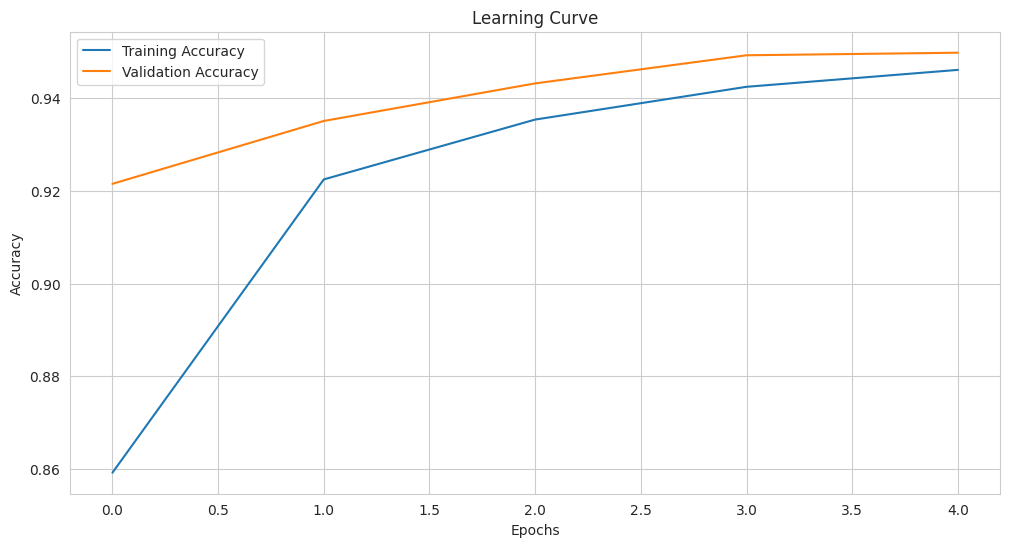

baseline_binary_dense_model training complete.

Training baseline_binary_cnn_model...
Epoch 1/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.6743 - loss: 0.5743 - val_accuracy: 0.8755 - val_loss: 0.2900
Epoch 2/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8761 - loss: 0.2864 - val_accuracy: 0.9050 - val_loss: 0.2254
Epoch 3/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9063 - loss: 0.2275 - val_accuracy: 0.9135 - val_loss: 0.2097
Epoch 4/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9209 - loss: 0.1994 - val_accuracy: 0.9139 - val_loss: 0.2115
Epoch 5/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9253 - loss: 0.1824 - val_accuracy: 0.9172 - val_loss: 0.2013


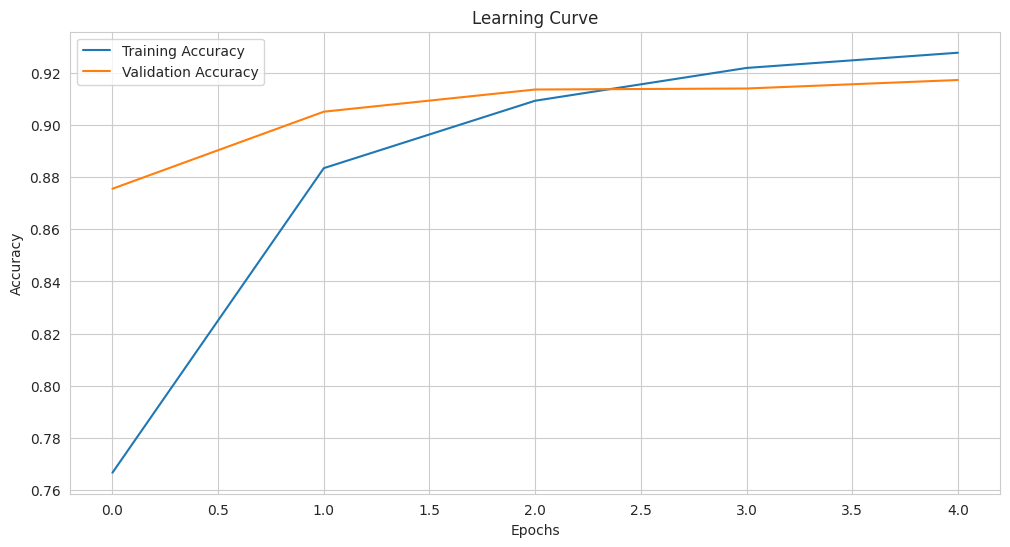

baseline_binary_cnn_model training complete.

Training baseline_binary_lstm_model...
Epoch 1/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8509 - loss: 0.2996 - val_accuracy: 0.9460 - val_loss: 0.1289
Epoch 2/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9521 - loss: 0.1158 - val_accuracy: 0.9573 - val_loss: 0.1022
Epoch 3/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9618 - loss: 0.0934 - val_accuracy: 0.9621 - val_loss: 0.0944
Epoch 4/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9666 - loss: 0.0817 - val_accuracy: 0.9676 - val_loss: 0.0806
Epoch 5/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9705 - loss: 0.0721 - val_accuracy: 0.9689 - val_loss: 0.0766


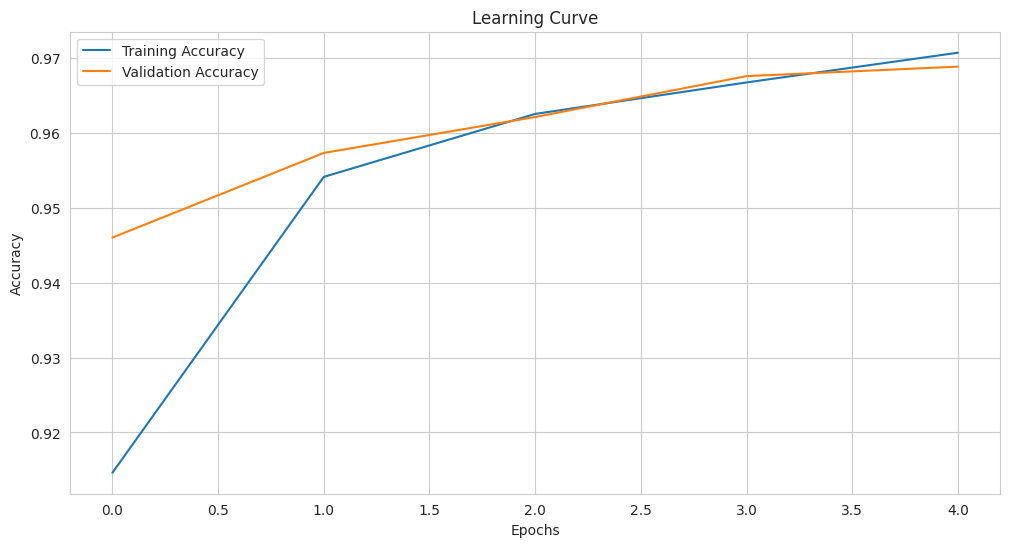

baseline_binary_lstm_model training complete.

Training baseline_binary_clstm_model...
Epoch 1/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8057 - loss: 0.3986 - val_accuracy: 0.9146 - val_loss: 0.1997
Epoch 2/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9245 - loss: 0.1793 - val_accuracy: 0.9301 - val_loss: 0.1669
Epoch 3/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9391 - loss: 0.1485 - val_accuracy: 0.9352 - val_loss: 0.1615
Epoch 4/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9473 - loss: 0.1311 - val_accuracy: 0.9366 - val_loss: 0.1607
Epoch 5/5
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9525 - loss: 0.1178 - val_accuracy: 0.9361 - val_loss: 0.1639


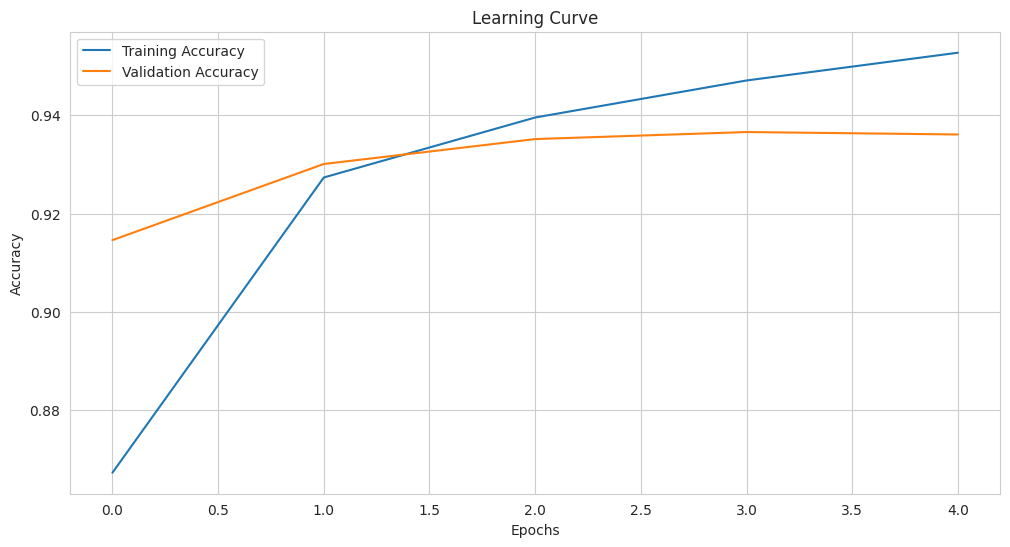

baseline_binary_clstm_model training complete.


In [ ]:
# Train all the binary baseline models
for model_name, model in {k: v for k,v in baseline_models.items() if 'binary' in k}.items():
    print(f"\nTraining {model_name}...")
    history = model.fit(X_train_binary_seq, y_train_binary_seq, epochs=5, batch_size=64, validation_data=(X_val_binary_seq, y_val_binary_seq))
    plot_learning_curve(history)

    print(f"{model_name} training complete.")


Training baseline_multi_dense_model...
Epoch 1/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.4326 - loss: 1.5850 - val_accuracy: 0.6243 - val_loss: 0.9805
Epoch 2/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.6008 - loss: 1.0523 - val_accuracy: 0.6510 - val_loss: 0.8958
Epoch 3/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.6240 - loss: 0.9774 - val_accuracy: 0.6626 - val_loss: 0.8492
Epoch 4/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.6411 - loss: 0.9307 - val_accuracy: 0.6769 - val_loss: 0.8193
Epoch 5/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.6508 - loss: 0.9027 - val_accuracy: 0.6877 - val_loss: 0.7966


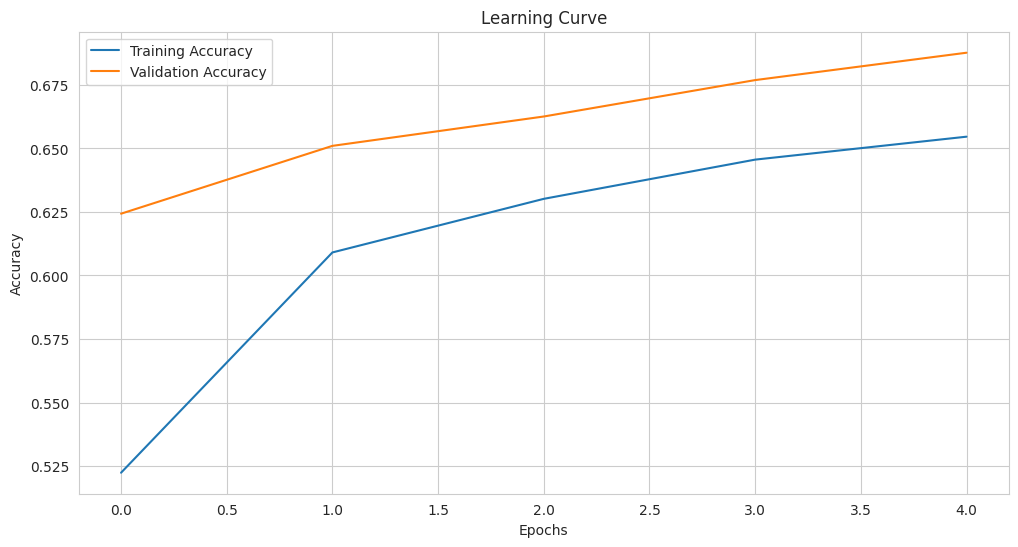

baseline_multi_dense_model training complete.

Training baseline_multi_cnn_model...
Epoch 1/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.1963 - loss: 2.1391 - val_accuracy: 0.3980 - val_loss: 1.6326
Epoch 2/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.3561 - loss: 1.7561 - val_accuracy: 0.4527 - val_loss: 1.4911
Epoch 3/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.3974 - loss: 1.6482 - val_accuracy: 0.4767 - val_loss: 1.4020
Epoch 4/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.4227 - loss: 1.5794 - val_accuracy: 0.4935 - val_loss: 1.3541
Epoch 5/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.4379 - loss: 1.5355 - val_accuracy: 0.5017 - val_loss: 1.3264


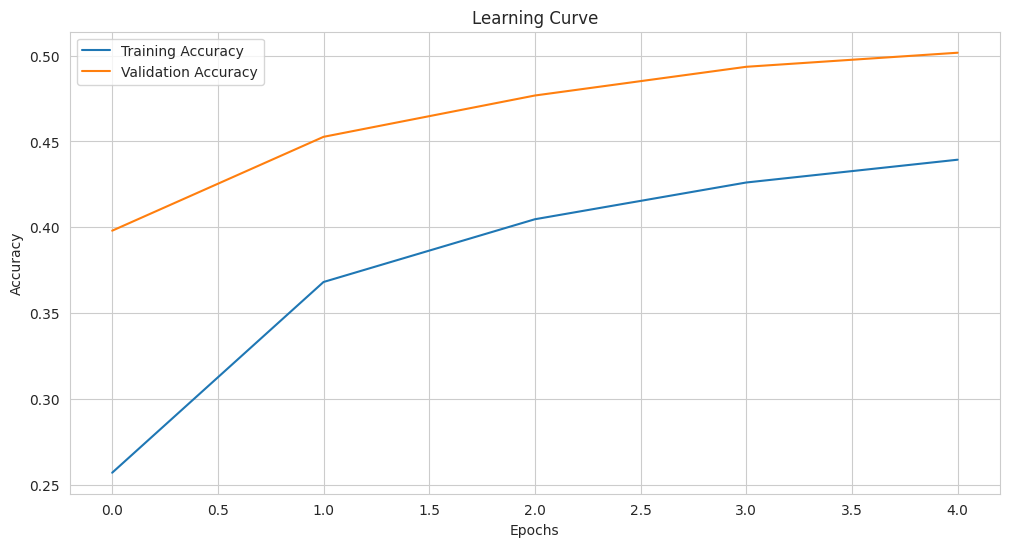

baseline_multi_cnn_model training complete.

Training baseline_multi_lstm_model...
Epoch 1/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 0.5411 - loss: 1.2372 - val_accuracy: 0.7080 - val_loss: 0.7639
Epoch 2/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - accuracy: 0.6935 - loss: 0.8031 - val_accuracy: 0.7314 - val_loss: 0.6858
Epoch 3/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 38s 8ms/step - accuracy: 0.7175 - loss: 0.7380 - val_accuracy: 0.7429 - val_loss: 0.6490
Epoch 4/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 0.7269 - loss: 0.7051 - val_accuracy: 0.7479 - val_loss: 0.6322
Epoch 5/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 39s 8ms/step - accuracy: 0.7326 - loss: 0.6834 - val_accuracy: 0.7516 - val_loss: 0.6148


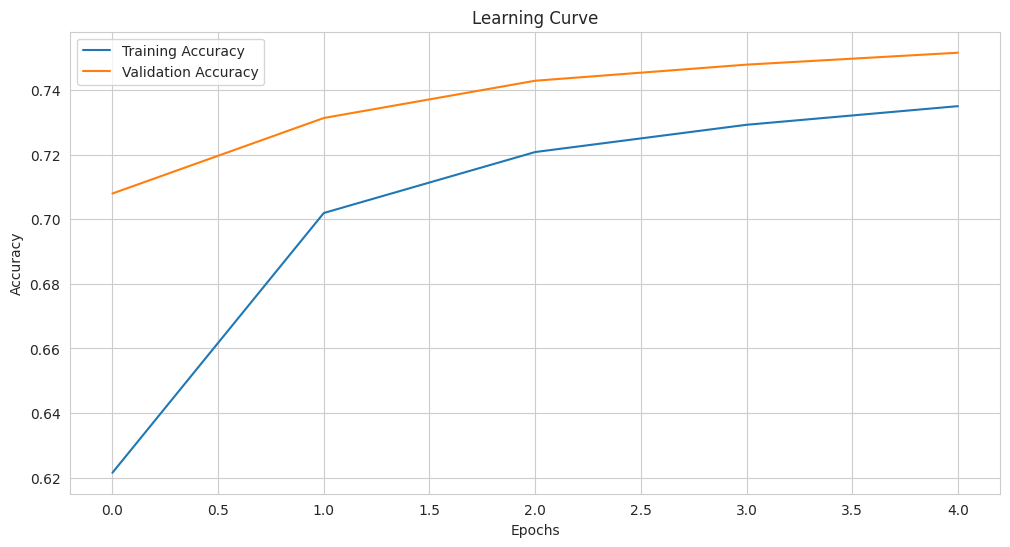

baseline_multi_lstm_model training complete.

Training baseline_multi_clstm_model...
Epoch 1/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 34s 7ms/step - accuracy: 0.4105 - loss: 1.6184 - val_accuracy: 0.5938 - val_loss: 1.0970
Epoch 2/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - accuracy: 0.5545 - loss: 1.1946 - val_accuracy: 0.6201 - val_loss: 1.0111
Epoch 3/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 32s 7ms/step - accuracy: 0.5837 - loss: 1.1111 - val_accuracy: 0.6362 - val_loss: 0.9605
Epoch 4/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - accuracy: 0.6001 - loss: 1.0638 - val_accuracy: 0.6515 - val_loss: 0.9249
Epoch 5/5
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 32s 7ms/step - accuracy: 0.6133 - loss: 1.0310 - val_accuracy: 0.6606 - val_loss: 0.9038


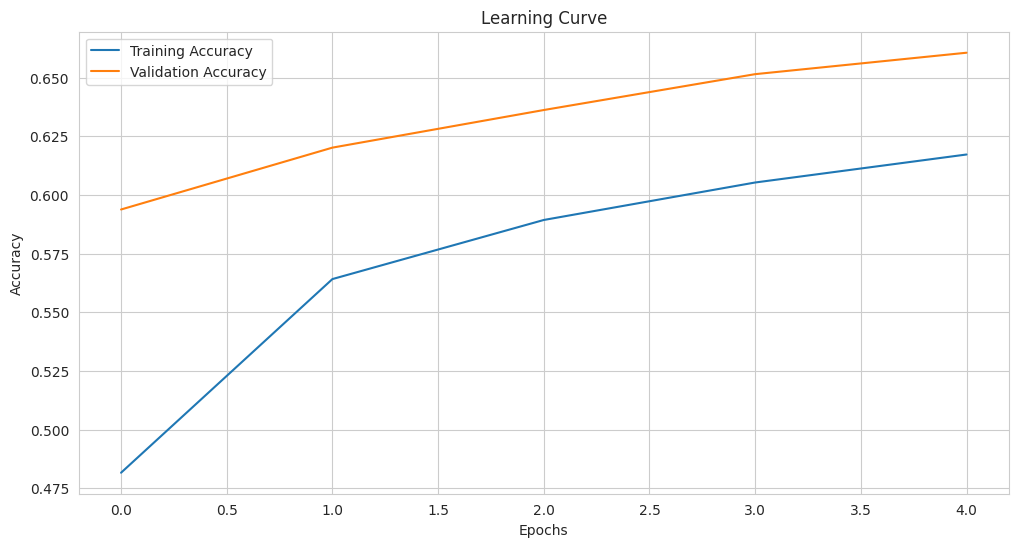

baseline_multi_clstm_model training complete.


In [ ]:
# Train the multi-class models
for model_name, model in {k:v for k,v in baseline_models.items() if 'multi' in k}.items():
    print(f"\nTraining {model_name}...")
    history = model.fit(X_train_multi_seq, y_train_multi_seq, epochs=5, batch_size=64, validation_data=(X_val_multi_seq, y_val_multi_seq))
    plot_learning_curve(history)

    print(f"{model_name} training complete.")

### Model Evaluation: Baseline Models

* Examine your models (coefficients, parameters, errors, etc...)
* Compute and interpret your results in terms of accuracy, precision, recall, ROC etc.

In [ ]:
# Here we layout model evaluation functions to be used throughout the remainder of the project

# Model Evaluation Functions
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix

def plot_learning_curve(history):
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Learning Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

def evaluate_model(y_test, y_pred_probs, binary):
    if binary:
      average = "binary"
      y_pred_labels = (y_pred_probs > 0.5).astype(int)
    else:
      average = "macro"
      y_pred_labels = np.argmax(y_pred_probs, axis=1)

    accuracy = accuracy_score(y_test, y_pred_labels)
    print(f'Test Accuracy: {accuracy:.2f}%')

    precision = precision_score(y_test, y_pred_labels, average=average)
    print(f'Test Precision: {precision:.2f}%')

    recall = recall_score(y_test, y_pred_labels, average=average)
    print(f'Test Recall: {recall:.2f}%')

    f1 = f1_score(y_test, y_pred_labels, average=average)
    print(f'Test F1 Score: {f1:.2f}%')

    if binary:
      fpr, tpr, thresh = roc_curve(y_test, y_pred_labels)
      auc_score = auc(fpr, tpr)
    else:
      auc_score = roc_auc_score(y_test, y_pred_probs,
                                multi_class='ovr', average=average)
      print(f'Test AUC: {auc_score:.2f}%')

    return {'accuracy': accuracy, 'precision': precision, 'recall': recall,
            'f1_score': f1, 'AUC': auc_score}

def plot_confusion_matrix(cm, class_names):
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = range(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

def evaluate_multiclass_model(y_true, y_pred, class_names):
    print(classification_report(y_true, y_pred, target_names=class_names))
    cm = confusion_matrix(y_true, y_pred)
    plot_confusion_matrix(cm, class_names)
    return cm

# Evaluate binary if we use normal vs abnormal classification
def evaluate_binary_model(y_true, y_pred):
    print(classification_report(y_true, y_pred, target_names=['Class 0', 'Class 1']))
    cm = confusion_matrix(y_true, y_pred)
    plot_confusion_matrix(cm, ['Class 0', 'Class 1'])
    return cm



Evaluating baseline_binary_dense_model...
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
              precision    recall  f1-score   support

     Class 0       0.33      0.90      0.48     55991
     Class 1       0.76      0.15      0.26    119341

    accuracy                           0.39    175332
   macro avg       0.54      0.52      0.37    175332
weighted avg       0.62      0.39      0.33    175332



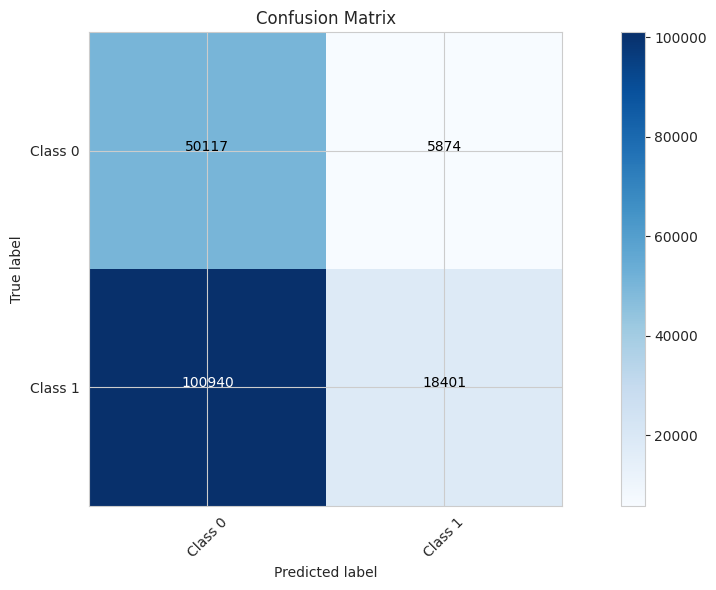

Test Accuracy: 0.39%
Test Precision: 0.76%
Test Recall: 0.15%
Test F1 Score: 0.26%
baseline_binary_dense_model evaluation complete.

Evaluating baseline_binary_cnn_model...
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
              precision    recall  f1-score   support

     Class 0       0.33      0.94      0.49     55991
     Class 1       0.80      0.11      0.20    119341

    accuracy                           0.38    175332
   macro avg       0.56      0.53      0.34    175332
weighted avg       0.65      0.38      0.29    175332



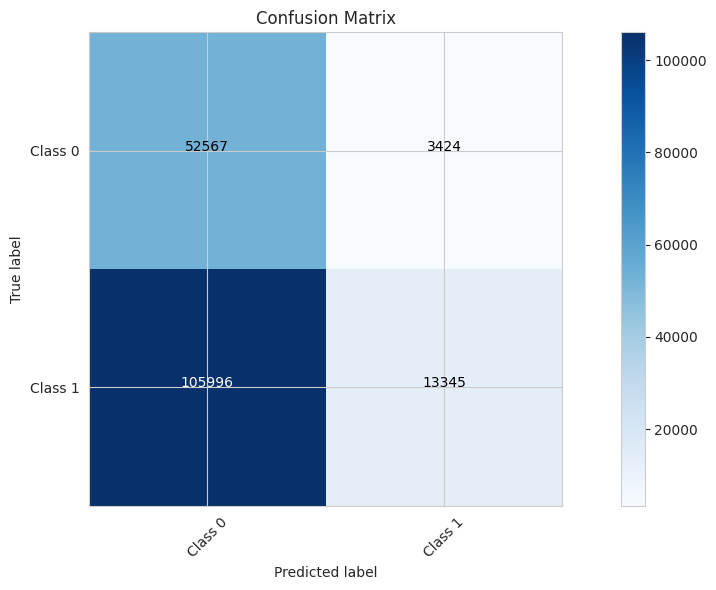

Test Accuracy: 0.38%
Test Precision: 0.80%
Test Recall: 0.11%
Test F1 Score: 0.20%
baseline_binary_cnn_model evaluation complete.

Evaluating baseline_binary_lstm_model...
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
              precision    recall  f1-score   support

     Class 0       0.33      0.93      0.49     55991
     Class 1       0.80      0.12      0.21    119341

    accuracy                           0.38    175332
   macro avg       0.57      0.53      0.35    175332
weighted avg       0.65      0.38      0.30    175332



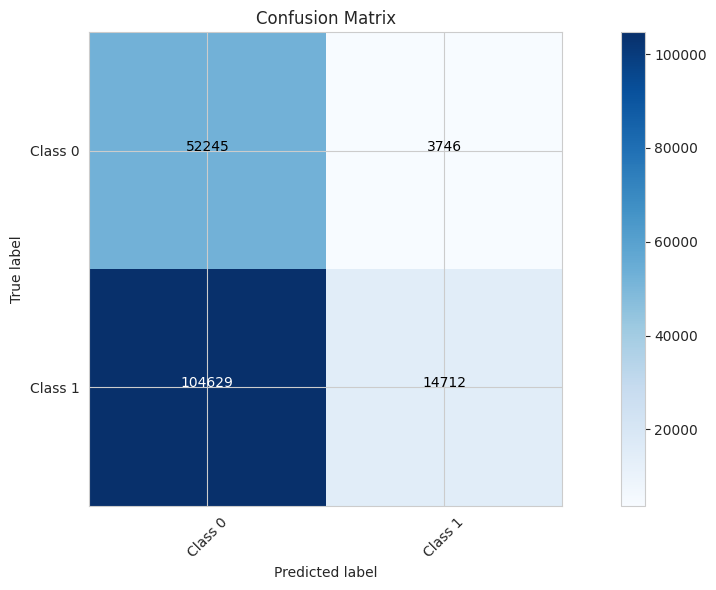

Test Accuracy: 0.38%
Test Precision: 0.80%
Test Recall: 0.12%
Test F1 Score: 0.21%
baseline_binary_lstm_model evaluation complete.

Evaluating baseline_binary_clstm_model...
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
              precision    recall  f1-score   support

     Class 0       0.35      0.89      0.50     55991
     Class 1       0.82      0.23      0.35    119341

    accuracy                           0.44    175332
   macro avg       0.59      0.56      0.43    175332
weighted avg       0.67      0.44      0.40    175332



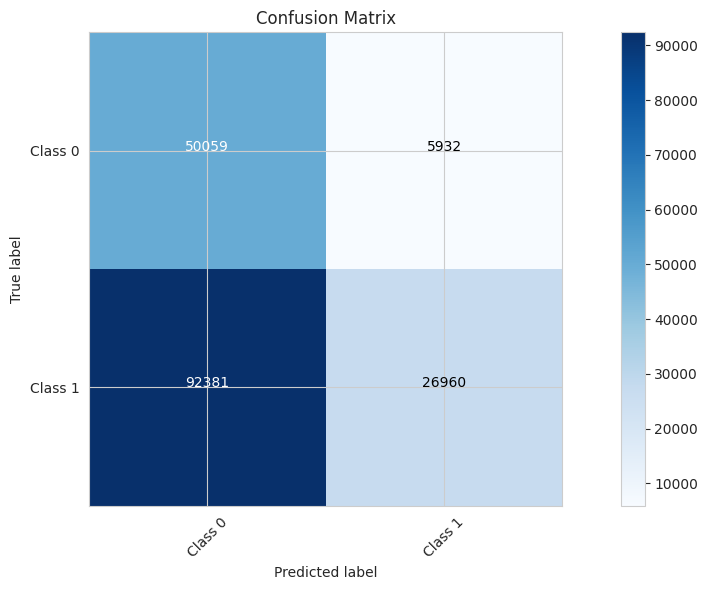

Test Accuracy: 0.44%
Test Precision: 0.82%
Test Recall: 0.23%
Test F1 Score: 0.35%
baseline_binary_clstm_model evaluation complete.

Evaluating baseline_multi_dense_model...
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
                precision    recall  f1-score   support

      Analysis       0.02      0.00      0.01      2000
      Backdoor       0.05      0.28      0.08      1746
           DoS       0.34      0.00      0.01     12264
      Exploits       0.84      0.15      0.26     33393
       Fuzzers       0.36      0.15      0.21     18184
       Generic       0.83      0.04      0.08     40000
        Normal       0.35      0.88      0.50     55991
Reconnaissance       0.46      0.19      0.27     10491
     Shellcode       0.08      0.16      0.10      1133
         Worms       0.02      0.25      0.04       130

      accuracy                           0.35    175332
     macro avg       0.34      0.21      0.16    175332
  weighted avg       0.55      0.35      0.27    1753

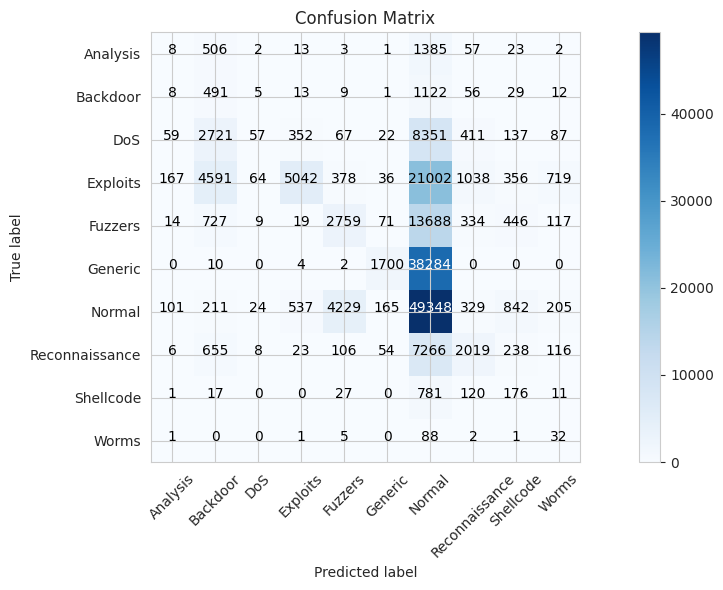

Test Accuracy: 0.35%
Test Precision: 0.34%
Test Recall: 0.21%
Test F1 Score: 0.16%
Test AUC: 0.70%
baseline_multi_dense_model evaluation complete.

Evaluating baseline_multi_cnn_model...
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
                precision    recall  f1-score   support

      Analysis       0.04      0.14      0.06      2000
      Backdoor       0.04      0.04      0.04      1746
           DoS       0.12      0.01      0.01     12264
      Exploits       0.56      0.10      0.16     33393
       Fuzzers       0.16      0.15      0.15     18184
       Generic       0.82      0.90      0.86     40000
        Normal       0.51      0.74      0.61     55991
Reconnaissance       0.29      0.01      0.02     10491
     Shellcode       0.04      0.35      0.07      1133
         Worms       0.01      0.61      0.03       130

      accuracy                           0.48    175332
     macro avg       0.26      0.31      0.20    175332
  weighted avg       0.50      0.48     

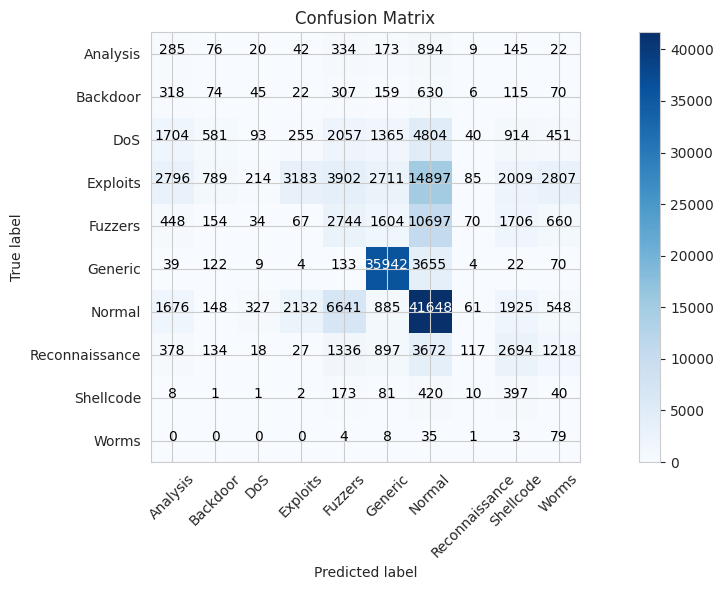

Test Accuracy: 0.48%
Test Precision: 0.26%
Test Recall: 0.31%
Test F1 Score: 0.20%
Test AUC: 0.77%
baseline_multi_cnn_model evaluation complete.

Evaluating baseline_multi_lstm_model...
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
                precision    recall  f1-score   support

      Analysis       0.04      0.00      0.00      2000
      Backdoor       0.06      0.16      0.09      1746
           DoS       0.23      0.01      0.01     12264
      Exploits       0.84      0.17      0.28     33393
       Fuzzers       0.33      0.09      0.14     18184
       Generic       0.92      0.09      0.16     40000
        Normal       0.35      0.93      0.51     55991
Reconnaissance       0.68      0.21      0.32     10491
     Shellcode       0.12      0.20      0.15      1133
         Worms       0.07      0.24      0.11       130

      accuracy                           0.37    175332
     macro avg       0.36      0.21      0.18    175332
  weighted avg       0.57      0.37     

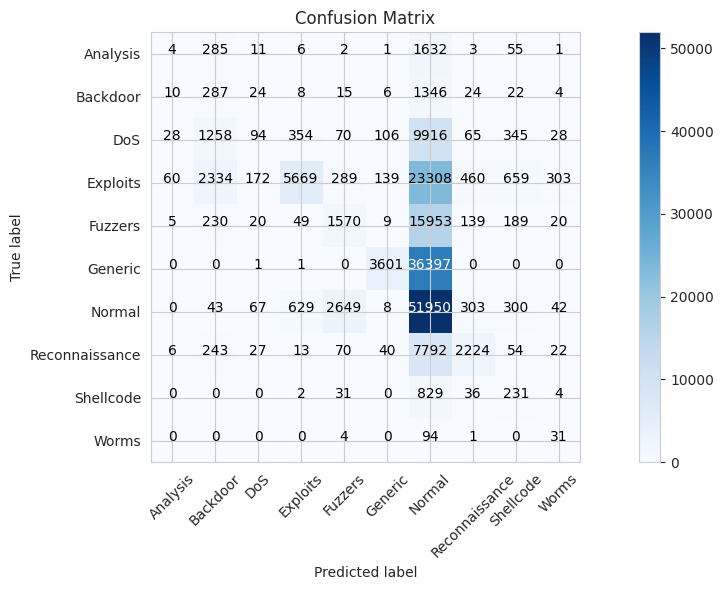

Test Accuracy: 0.37%
Test Precision: 0.36%
Test Recall: 0.21%
Test F1 Score: 0.18%
Test AUC: 0.75%
baseline_multi_lstm_model evaluation complete.

Evaluating baseline_multi_clstm_model...
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
                precision    recall  f1-score   support

      Analysis       0.05      0.02      0.03      2000
      Backdoor       0.05      0.32      0.09      1746
           DoS       0.09      0.01      0.01     12264
      Exploits       0.70      0.14      0.23     33393
       Fuzzers       0.31      0.14      0.19     18184
       Generic       0.90      0.98      0.94     40000
        Normal       0.50      0.85      0.63     55991
Reconnaissance       0.47      0.18      0.26     10491
     Shellcode       0.08      0.19      0.11      1133
         Worms       0.02      0.42      0.04       130

      accuracy                           0.55    175332
     macro avg       0.32      0.32      0.25    175332
  weighted avg       0.57      0.55   

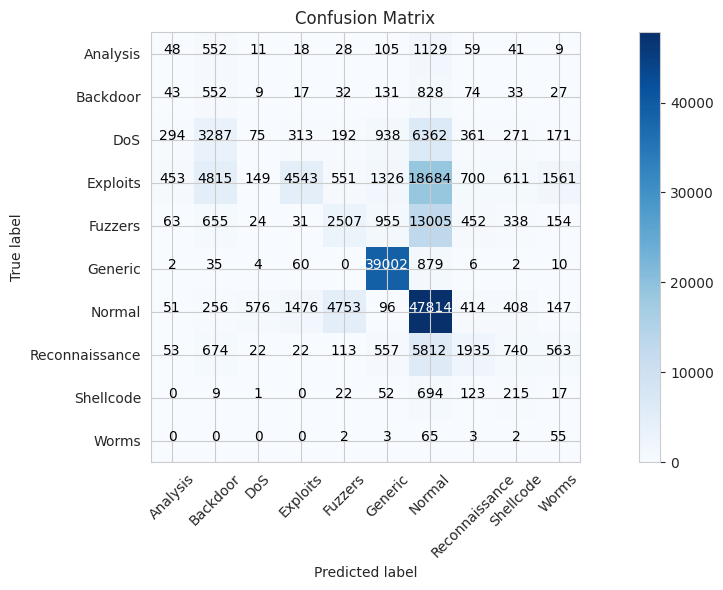

Test Accuracy: 0.55%
Test Precision: 0.32%
Test Recall: 0.32%
Test F1 Score: 0.25%
Test AUC: 0.84%
baseline_multi_clstm_model evaluation complete.


,accuracy,precision,recall,f1_score,AUC,Model
0,0.390790,0.758023,0.154188,0.256253,0.524639,baseline_binary_dense_model
1,0.375927,0.795814,0.111822,0.196091,0.525335,baseline_binary_cnn_model
2,0.381887,0.797053,0.123277,0.213528,0.528187,baseline_binary_lstm_model
3,0.439275,0.819652,0.225907,0.354194,0.559981,baseline_binary_clstm_model
4,0.351516,0.335596,0.211038,0.157184,0.703012,baseline_multi_dense_model
5,0.482296,0.258141,0.305031,0.201116,0.767528,baseline_multi_cnn_model
6,0.374495,0.364399,0.210234,0.178224,0.754075,baseline_multi_lstm_model
7,0.551787,0.316688,0.324647,0.253591,0.838850,baseline_multi_clstm_model


In [ ]:
# Evaluate all the models and compare
metrics_df = pd.DataFrame()

for model_name, model in baseline_models.items():
    print(f"\nEvaluating {model_name}...")
    if 'binary' in model_name:
        y_pred_probs = model.predict(X_test_binary_seq)
        y_pred = (y_pred_probs > 0.5).astype(int)
        evaluate_binary_model(y_test_binary_seq, y_pred)
        metrics = evaluate_model(y_test_binary_seq, y_pred_probs, binary=True)
    else:
        y_pred_probs = model.predict(X_test_multi_seq)
        y_pred = np.argmax(y_pred_probs, axis=1)
        class_names = [attack_le.inverse_transform([i])[0] for i in range(len(attack_le.classes_))]
        evaluate_multiclass_model(y_test_multi_seq, y_pred, class_names)
        metrics = evaluate_model(y_test_multi_seq, y_pred_probs, binary=False)

    metrics['Model'] = model_name
    metrics_row = pd.DataFrame([metrics])
    metrics_df = pd.concat([metrics_df, metrics_row], ignore_index=True)
    print(f"{model_name} evaluation complete.")

metrics_df

In [ ]:
# Save all the models
import joblib
# Set custom local dir for saving
local_dir = './drive/MyDrive/Colab Notebooks/Penn State Deep Learning'
for model_name, model in baseline_models.items():
    joblib.dump(model, f'{local_dir}/{model_name}.pkl')
    print(f"{model_name} saved.")

baseline_binary_dense_model saved.
baseline_binary_cnn_model saved.
baseline_binary_lstm_model saved.
baseline_binary_clstm_model saved.
baseline_multi_dense_model saved.
baseline_multi_cnn_model saved.
baseline_multi_lstm_model saved.
baseline_multi_clstm_model saved.


### Methodology

1. Explain your Deep Learning process / methodology




2. Introduce the Deep Neural Networks you used in your project
 * Model 1: CLSTM
    * The CLSTM model is a hybrid approach that combines the spatial pattern recognition strengths of a Convolutional Neural Network (CNN) model with the temporal pattern recognition strengths of a Long Short Term Memory (LSTM) model. This combination can yield impressive results when working with data that has both spatial and temporal, or time-series, attributes such as video or network traffic.

 * Model 2: Bi-CLSTM
    * Description

 * Model 3: ConvLSTM
     * The ConvLSTM model architecture is an advancement on the traditional LSTM architecture, incorporating convolutional operations in the LSTM itself. This model architecture is in contrast to the CLSTM where convolutional layers are combined with traditional LSTM layers. Combining convolutional operations into the LSTM has proven advantageous for these types of modeling tasks and has produced top tier performance on this dataset.


3. Add keywords  
**Keywords:**  Convolutional LSTM, binary classification, multi-label classification

### Model Fitting and Validation

BUILDING C-LSTM MODELS FOR INTRUSION DETECTION

Architecture: CNN → LSTM → Dense
- CNN extracts spatial patterns from network traffic features
- LSTM aggregates information across the sequence window
- Dense layers perform final classification


1. BINARY CLASSIFICATION C-LSTM

Input shape: (10 timesteps, 49 features)
Output: Binary (0=Normal, 1=Attack)
Loss: Binary crossentropy
Metrics: Accuracy, AUC

Model Summary:


Model: "C-LSTM_2class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 10, 64)         │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 10, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 10, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 10, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool (MaxPooling1D)          │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        91,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,329 (520.82 KB)

 Trainable params: 132,817 (518.82 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 10, 64)         │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 10, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 10, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 10, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool (MaxPooling1D)          │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        91,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,914 (523.10 KB)

 Trainable params: 133,402 (521.10 KB)

 Non-trainable params: 512 (2.00 KB)


TRAINING CONFIGURATION

Callbacks:
  - Early Stopping: patience=7, restores best weights
  - Learning Rate Reduction: factor=0.5, patience=3

Training Parameters:
  - Epochs: 25 (with early stopping)
  - Batch size: 64
  - Optimizer: Adam (lr=0.001, gradient clipping)

TRAINING BINARY CLASSIFICATION C-LSTM
Training samples:   72,522
Validation samples: 18,124
Test samples:       175,332

Epoch 1/25
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - AUC: 0.8859 - accuracy: 0.8083 - loss: 0.4599 - val_AUC: 0.9899 - val_accuracy: 0.9485 - val_loss: 0.1729 - learning_rate: 0.0010
Epoch 2/25
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - AUC: 0.9867 - accuracy: 0.9429 - loss: 0.1886 - val_AUC: 0.9936 - val_accuracy: 0.9566 - val_loss: 0.1390 - learning_rate: 0.0010
Epoch 3/25
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - AUC: 0.9917 - accuracy: 0.9544 - loss: 0.1495 - val_AUC: 0.9952 - val_accuracy: 0.9653 - val_loss: 0.1189 - learning_rate: 0.0010
Epoch 4/25
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 15

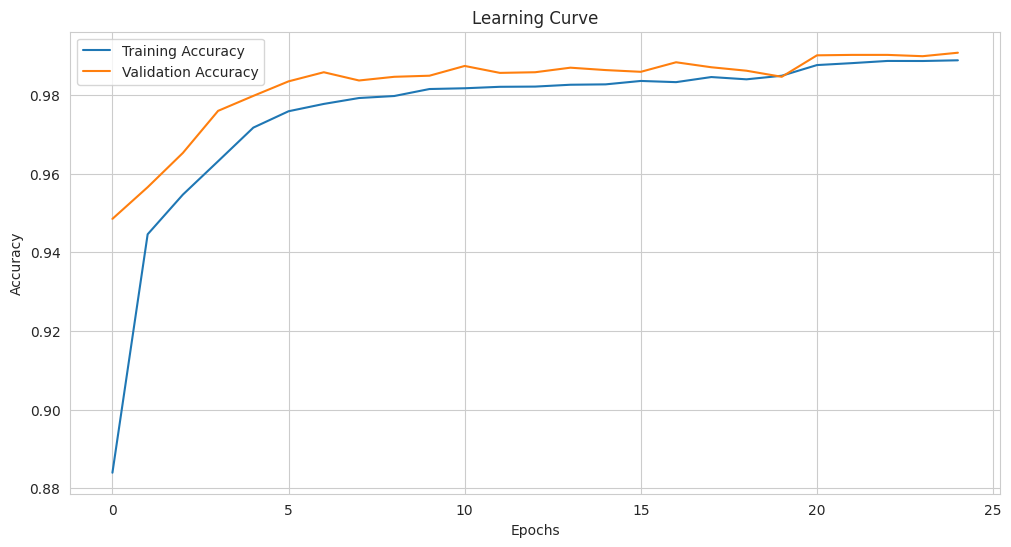


TRAINING MULTI-CLASS CLASSIFICATION C-LSTM
Training samples:   295,991
Validation samples: 73,991
Test samples:       175,332

Epoch 1/25
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 64s 13ms/step - accuracy: 0.4803 - loss: 1.5219 - val_accuracy: 0.6891 - val_loss: 0.8573 - learning_rate: 0.0010
Epoch 2/25
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 58s 13ms/step - accuracy: 0.6671 - loss: 0.9399 - val_accuracy: 0.7179 - val_loss: 0.7895 - learning_rate: 0.0010
Epoch 3/25
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 60s 13ms/step - accuracy: 0.6942 - loss: 0.8771 - val_accuracy: 0.7255 - val_loss: 0.7640 - learning_rate: 0.0010
Epoch 4/25
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 59s 13ms/step - accuracy: 0.7081 - loss: 0.8454 - val_accuracy: 0.7390 - val_loss: 0.7327 - learning_rate: 0.0010
Epoch 5/25
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 59s 13ms/step - accuracy: 0.7129 - loss: 0.8295 - val_accuracy: 0.7409 - val_loss: 0.7283 - learning_rate: 0.0010
Epoch 6/25
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 59s 13ms/step - accuracy: 0.7159 - loss: 0.8237 - 

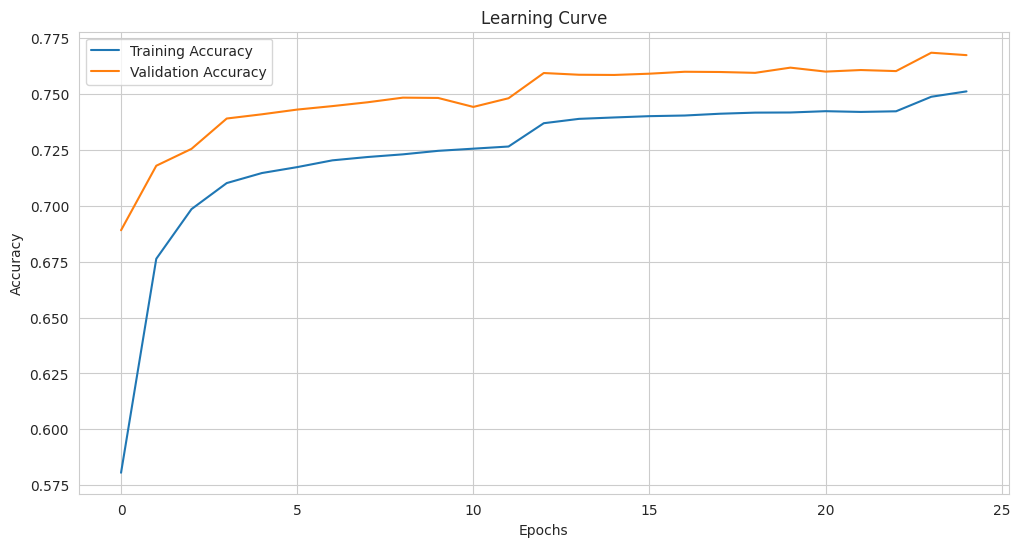


C-LSTM TRAINING COMPLETED

Model Architecture:
  → Conv1D (64 filters, k=3) + BatchNorm + Dropout
  → Conv1D (128 filters, k=3) + BatchNorm + MaxPool + Dropout
  → LSTM (100 units) + Dropout
  → Dense (64 units) + BatchNorm + Dropout
  → Output layer (sigmoid/softmax)

Next: Evaluate models on test set and compare with baselines


In [ ]:
# C-LSTM implementation and training
# ============================================================================
# C-LSTM IMPLEMENTATION - Convolutional-LSTM Hybrid Architecture
# ============================================================================
#
# ARCHITECTURE OVERVIEW:
# ----------------------
# This C-LSTM (CNN-LSTM) model combines two complementary approaches:
#   1. CNN layers: Extract spatial patterns from network traffic features
#   2. LSTM layer: Aggregate sequential information across the flow window
#   3. Dense layers: Perform final classification
#
# DESIGN RATIONALE:
# -----------------
# - CNN extracts local feature patterns (e.g., byte distributions, packet ratios)
# - LSTM captures dependencies across the sequence of flows
# - Moderate regularization balances learning capacity with generalization
# - Works for both binary (Normal/Attack) and multi-class (Attack Types)
#
# NOTE: The UNSW-NB15 dataset contains independent network flows. The sequence
# dimension (TIME_STEPS=10) groups flows together, which may or may not have
# true temporal relationships. Compare results against baseline models to
# assess whether the added complexity provides value.
#
# ============================================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

TIME_STEPS = 10

def build_clstm_model(input_shape, num_classes):
    """
    Build a C-LSTM (CNN-LSTM) hybrid model for network intrusion detection

    Architecture:
        Conv1D (64 filters) → BatchNorm → Dropout
        → Conv1D (128 filters) → BatchNorm → MaxPooling → Dropout
        → LSTM (100 units) → Dropout
        → Dense (64 units) → BatchNorm → Dropout
        → Output (sigmoid/softmax)

    Args:
        input_shape: tuple (timesteps, features) - e.g., (10, 45)
        num_classes: int - 2 for binary, N for multi-class classification

    Returns:
        Compiled Keras Sequential model
    """
    model = Sequential(name=f"C-LSTM_{num_classes}class")

    # ========================================================================
    # CNN BLOCK 1: First Convolutional Layer
    # ========================================================================
    # Extract low-level local patterns from feature sequences
    model.add(
        Conv1D(
            filters=64,
            kernel_size=3,
            activation="relu",
            padding="same",
            input_shape=input_shape,
            kernel_regularizer=l2(0.0001),
            name="conv1d_1",
        )
    )
    model.add(BatchNormalization(name="bn_1"))
    model.add(Dropout(0.3, name="dropout_1"))

    # ========================================================================
    # CNN BLOCK 2: Second Convolutional Layer
    # ========================================================================
    # Combine low-level patterns into higher-level features
    model.add(
        Conv1D(
            filters=128,
            kernel_size=3,
            activation="relu",
            padding="same",
            kernel_regularizer=l2(0.0001),
            name="conv1d_2",
        )
    )
    model.add(BatchNormalization(name="bn_2"))
    model.add(MaxPooling1D(pool_size=2, name="maxpool"))
    model.add(Dropout(0.3, name="dropout_2"))

    # ========================================================================
    # LSTM BLOCK: Sequential Feature Aggregation
    # ========================================================================
    # Aggregate CNN-extracted features across the sequence dimension
    # return_sequences=False: Output only final aggregated state
    model.add(
        LSTM(
            100,
            kernel_regularizer=l2(0.0001),
            recurrent_regularizer=l2(0.0001),
            return_sequences=False,
            name="lstm",
        )
    )
    model.add(Dropout(0.3, name="dropout_3"))

    # ========================================================================
    # DENSE BLOCK: Classification Layer
    # ========================================================================
    # Learn decision boundaries from aggregated LSTM features
    model.add(
        Dense(64, activation="relu", kernel_regularizer=l2(0.0001), name="dense_hidden")
    )
    model.add(BatchNormalization(name="bn_3"))
    model.add(Dropout(0.3, name="dropout_4"))

    # ========================================================================
    # OUTPUT LAYER: Task-Specific
    # ========================================================================
    if num_classes == 2:
        # Binary classification: sigmoid activation
        model.add(Dense(1, activation="sigmoid", name="output"))
        loss = "binary_crossentropy"
        metrics = ["accuracy", "AUC"]
    else:
        # Multi-class classification: softmax activation
        model.add(Dense(num_classes, activation="softmax", name="output"))
        loss = "sparse_categorical_crossentropy"
        metrics = ["accuracy"]

    # ========================================================================
    # MODEL COMPILATION
    # ========================================================================
    optimizer = Adam(
        learning_rate=0.001,
        clipnorm=1.0,  # Prevent exploding gradients
    )

    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    return model


# ============================================================================
# BUILD C-LSTM MODELS
# ============================================================================

print("=" * 80)
print("BUILDING C-LSTM MODELS FOR INTRUSION DETECTION")
print("=" * 80)
print("\nArchitecture: CNN → LSTM → Dense")
print("- CNN extracts spatial patterns from network traffic features")
print("- LSTM aggregates information across the sequence window")
print("- Dense layers perform final classification")
print()

# ----------------------------------------------------------------------------
# Binary Classification C-LSTM (Normal vs Attack)
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("1. BINARY CLASSIFICATION C-LSTM")
print("=" * 80)

clstm_binary = build_clstm_model(
    input_shape=(TIME_STEPS, X_train_binary_seq.shape[2]), num_classes=2
)

print(
    f"\nInput shape: ({TIME_STEPS} timesteps, {X_train_binary_seq.shape[2]} features)"
)
print(f"Output: Binary (0=Normal, 1=Attack)")
print(f"Loss: Binary crossentropy")
print(f"Metrics: Accuracy, AUC")
print("\nModel Summary:")
clstm_binary.summary()

# ----------------------------------------------------------------------------
# Multi-class Classification C-LSTM (Attack Type Detection)
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("2. MULTI-CLASS CLASSIFICATION C-LSTM")
print("=" * 80)

n_attack_classes = len(np.unique(y_train_multi_seq))

clstm_multi = build_clstm_model(
    input_shape=(TIME_STEPS, X_train_multi_seq.shape[2]), num_classes=n_attack_classes
)

print(f"\nInput shape: ({TIME_STEPS} timesteps, {X_train_multi_seq.shape[2]} features)")
print(f"Output: {n_attack_classes} attack categories")
print(f"Loss: Sparse categorical crossentropy")
print(f"Metrics: Accuracy")
print("\nModel Summary:")
clstm_multi.summary()

# ============================================================================
# TRAINING CONFIGURATION
# ============================================================================
print("\n" + "=" * 80)
print("TRAINING CONFIGURATION")
print("=" * 80)

# Callbacks for robust training
early_stopping = EarlyStopping(
    monitor="val_loss", patience=7, restore_best_weights=True, verbose=1, mode="min"
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1, mode="min"
)

callbacks_list = [early_stopping, reduce_lr]

print("\nCallbacks:")
print("  - Early Stopping: patience=7, restores best weights")
print("  - Learning Rate Reduction: factor=0.5, patience=3")
print("\nTraining Parameters:")
print("  - Epochs: 25 (with early stopping)")
print("  - Batch size: 64")
print("  - Optimizer: Adam (lr=0.001, gradient clipping)")

# ============================================================================
# TRAIN BINARY CLASSIFICATION C-LSTM
# ============================================================================
print("\n" + "=" * 80)
print("TRAINING BINARY CLASSIFICATION C-LSTM")
print("=" * 80)
print(f"Training samples:   {X_train_binary_seq.shape[0]:,}")
print(f"Validation samples: {X_val_binary_seq.shape[0]:,}")
print(f"Test samples:       {X_test_binary_seq.shape[0]:,}")
print()

clstm_binary_history = clstm_binary.fit(
    X_train_binary_seq,
    y_train_binary_seq,
    epochs=25,
    batch_size=64,
    validation_data=(X_val_binary_seq, y_val_binary_seq),
    callbacks=callbacks_list,
    verbose=1,
)

print("\n✓ Binary C-LSTM training complete!")
plot_learning_curve(clstm_binary_history)

# ============================================================================
# TRAIN MULTI-CLASS CLASSIFICATION C-LSTM
# ============================================================================
print("\n" + "=" * 80)
print("TRAINING MULTI-CLASS CLASSIFICATION C-LSTM")
print("=" * 80)
print(f"Training samples:   {X_train_multi_seq.shape[0]:,}")
print(f"Validation samples: {X_val_multi_seq.shape[0]:,}")
print(f"Test samples:       {X_test_multi_seq.shape[0]:,}")
print()

clstm_multi_history = clstm_multi.fit(
    X_train_multi_seq,
    y_train_multi_seq,
    epochs=25,
    batch_size=64,
    validation_data=(X_val_multi_seq, y_val_multi_seq),
    callbacks=callbacks_list,
    verbose=1,
)

print("\n✓ Multi-class C-LSTM training complete!")
plot_learning_curve(clstm_multi_history)

# ============================================================================
# TRAINING SUMMARY
# ============================================================================
print("\n" + "=" * 80)
print("C-LSTM TRAINING COMPLETED")
print("=" * 80)
print("\nModel Architecture:")
print("  → Conv1D (64 filters, k=3) + BatchNorm + Dropout")
print("  → Conv1D (128 filters, k=3) + BatchNorm + MaxPool + Dropout")
print("  → LSTM (100 units) + Dropout")
print("  → Dense (64 units) + BatchNorm + Dropout")
print("  → Output layer (sigmoid/softmax)")
print("\nNext: Evaluate models on test set and compare with baselines")


PREPARING DATA - MATCHING TEST DISTRIBUTION
Test: 31.9% Normal, 68.1% Attack
Original: 37000 Normal, 45332 Attack
Balanced: 21271 Normal, 45332 Attack

Binary - Train: (53273, 10, 49), Val: (13312, 10, 49), Test: (175332, 10, 49)
Multi  - Train: (65856, 10, 49), Val: (16458, 10, 49), Test: (175332, 10, 49)

✓ Data ready!
BUILDING C-BiLSTM MODELS
Input shape: (10, 49)
Classes: Binary=2, Multi=10

✓ Models built!


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 10, 64)         │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 10, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 10, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,273 (712.00 KB)

 Trainable params: 181,377 (708.50 KB)

 Non-trainable params: 896 (3.50 KB)

TRAINING BINARY C-BiLSTM
Epoch 1/20
833/833 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.7427 - loss: 1.1913 - val_accuracy: 0.9608 - val_loss: 0.4944 - learning_rate: 0.0010
Epoch 2/20
833/833 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9516 - loss: 0.4553 - val_accuracy: 0.9699 - val_loss: 0.2610 - learning_rate: 0.0010
Epoch 3/20
833/833 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9635 - loss: 0.2532 - val_accuracy: 0.9758 - val_loss: 0.1650 - learning_rate: 0.0010
Epoch 4/20
833/833 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9664 - loss: 0.1818 - val_accuracy: 0.9750 - val_loss: 0.1354 - learning_rate: 0.0010
Epoch 5/20
833/833 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.9700 - loss: 0.1449 - val_accuracy: 0.9772 - val_loss: 0.1142 - learning_rate: 0.0010
Epoch 6/20
833/833 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.9757 - loss: 0.1212 - val_accuracy: 0.9827 - val_loss: 0.1014 - learning_rate: 0.0010
Epoch 7/20
833/833 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/st

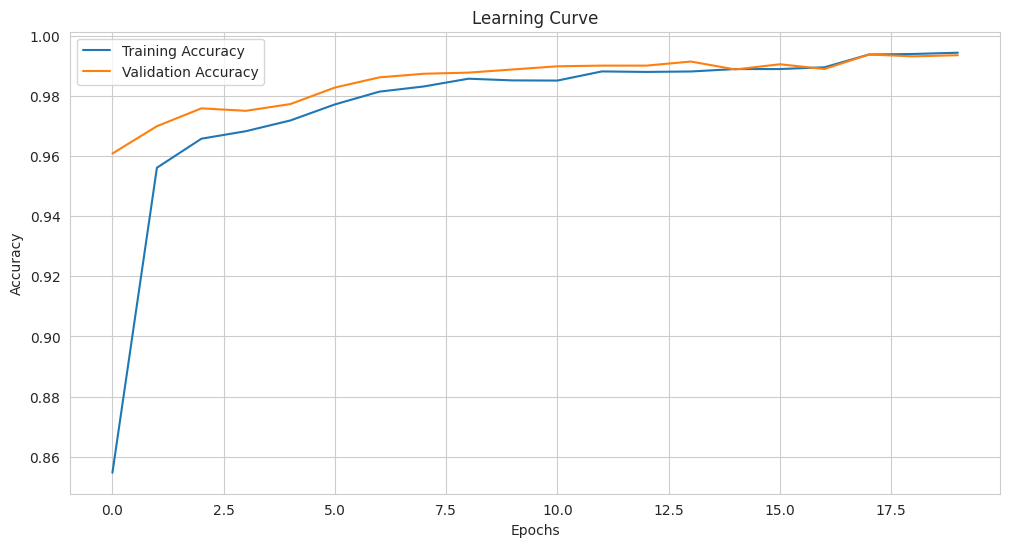


✓ Binary training complete!
TRAINING MULTI-CLASS C-BiLSTM
Epoch 1/20
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.2537 - loss: 3.6063 - val_accuracy: 0.5346 - val_loss: 2.0563 - learning_rate: 0.0010
Epoch 2/20
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.6051 - loss: 2.4900 - val_accuracy: 0.6726 - val_loss: 1.3313 - learning_rate: 0.0010
Epoch 3/20
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.7122 - loss: 1.9714 - val_accuracy: 0.7626 - val_loss: 1.0380 - learning_rate: 0.0010
Epoch 4/20
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.7530 - loss: 1.7147 - val_accuracy: 0.7780 - val_loss: 0.9468 - learning_rate: 0.0010
Epoch 5/20
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.7673 - loss: 1.6212 - val_accuracy: 0.7822 - val_loss: 0.8828 - learning_rate: 0.0010
Epoch 6/20
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.7703 - loss: 1.5487 - val_accuracy: 0.7715 - val_loss: 0.9154 - learning_rate: 0.0010
Epoch

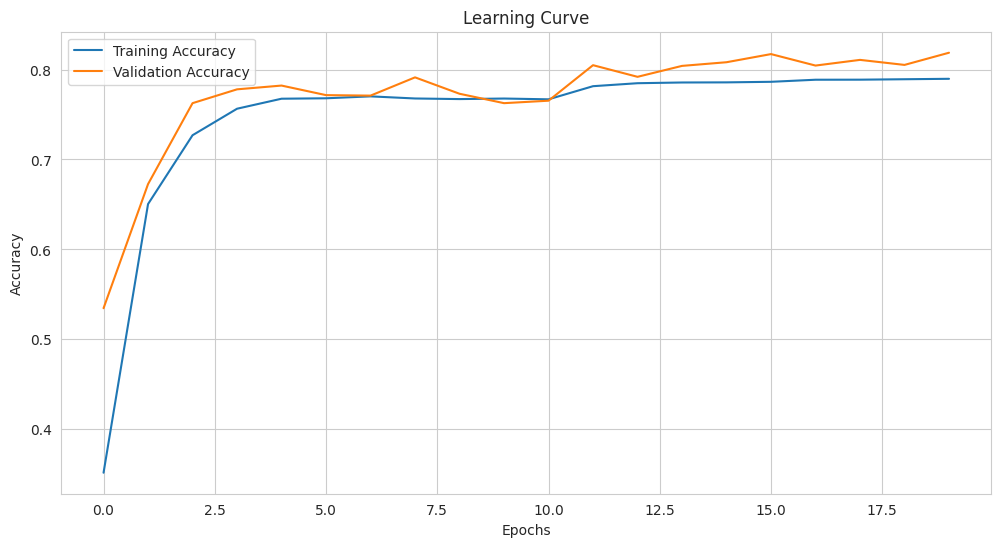


✓ Multi-class training complete!
FINDING OPTIMAL THRESHOLD
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step

Probability stats: Mean=0.145, Median=0.000

Thresh   Acc        F1         Precision  Recall    
--------------------------------------------------
0.10     37.32      25.48      66.80      15.74     
0.15     37.38      25.34      67.20      15.62     
0.20     37.40      25.24      67.47      15.52     
0.25     37.43      25.12      67.71      15.42     
0.30     37.45      25.01      67.96      15.33     
0.35     37.48      24.92      68.26      15.24     
0.40     37.50      24.79      68.49      15.13     
0.45     37.54      24.69      68.83      15.04     
0.50     37.58      24.63      69.16      14.98     
0.55     37.61      24.53      69.45      14.90     
0.60     37.67      24.46      69.87      14.82     
0.65     37.75      24.35      70.43      14.72     
0.70     37.82      24.24      71.04      14.61     
0.75     37.93      24.13      71.84      14.50     
0.80

In [ ]:
# ============================================================================
# C-BiLSTM COMPLETE SOLUTION - RELIABLE VERSION
# ============================================================================
# This version matches training distribution to test distribution
# for consistent, reliable results

# ============================================================================
# CELL 1: PREPARE DATA - MATCH TEST DISTRIBUTION
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print("="*70)
print("PREPARING DATA - MATCHING TEST DISTRIBUTION")
print("="*70)

y_bin = y_train_binary.values if hasattr(y_train_binary, 'values') else y_train_binary
y_test_bin_np = y_test_binary.values if hasattr(y_test_binary, 'values') else y_test_binary

# Convert X_train to numpy if it's a DataFrame
X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

test_ratio = (y_test_bin_np == 0).sum() / len(y_test_bin_np)
print(f"Test: {test_ratio*100:.1f}% Normal, {(1-test_ratio)*100:.1f}% Attack")

normal_idx = np.where(y_bin == 0)[0]
attack_idx = np.where(y_bin == 1)[0]
print(f"Original: {len(normal_idx)} Normal, {len(attack_idx)} Attack")

n_normal_target = int(len(attack_idx) * test_ratio / (1 - test_ratio))

np.random.seed(42)
normal_idx_sampled = np.random.choice(normal_idx, size=min(n_normal_target, len(normal_idx)), replace=False)
selected_idx = np.concatenate([normal_idx_sampled, attack_idx])
np.random.shuffle(selected_idx)

X_train_balanced = X_train_np[selected_idx]
y_train_balanced = y_bin[selected_idx]
print(f"Balanced: {(y_train_balanced==0).sum()} Normal, {(y_train_balanced==1).sum()} Attack")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test_np)

def create_seq(X, y, steps=10):
    Xs, ys = [], []
    for i in range(len(X) - steps + 1):
        Xs.append(X[i:(i + steps)])
        ys.append(y[i + steps - 1])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 10

X_tr, X_vl, y_tr, y_vl = train_test_split(X_train_scaled, y_train_balanced, test_size=0.2, random_state=42, stratify=y_train_balanced)
X_train_seq, y_train_seq = create_seq(X_tr, y_tr, TIME_STEPS)
X_val_seq, y_val_seq = create_seq(X_vl, y_vl, TIME_STEPS)
X_test_seq, y_test_seq = create_seq(X_test_scaled, y_test_bin_np, TIME_STEPS)

y_multi = y_train_multi.values if hasattr(y_train_multi, 'values') else y_train_multi
y_test_multi_np = y_test_multi.values if hasattr(y_test_multi, 'values') else y_test_multi

scaler_multi = StandardScaler()
X_train_multi_scaled = scaler_multi.fit_transform(X_train_np)
X_test_multi_scaled = scaler_multi.transform(X_test_np)

X_tr_m, X_vl_m, y_tr_m, y_vl_m = train_test_split(X_train_multi_scaled, y_multi, test_size=0.2, random_state=42, stratify=y_multi)
X_train_multi_seq, y_train_multi_seq = create_seq(X_tr_m, y_tr_m, TIME_STEPS)
X_val_multi_seq, y_val_multi_seq = create_seq(X_vl_m, y_vl_m, TIME_STEPS)
X_test_multi_seq, y_test_multi_seq = create_seq(X_test_multi_scaled, y_test_multi_np, TIME_STEPS)

cw_multi = compute_class_weight('balanced', classes=np.unique(y_train_multi_seq), y=y_train_multi_seq)
multi_class_weights = dict(enumerate(cw_multi))

print(f"\nBinary - Train: {X_train_seq.shape}, Val: {X_val_seq.shape}, Test: {X_test_seq.shape}")
print(f"Multi  - Train: {X_train_multi_seq.shape}, Val: {X_val_multi_seq.shape}, Test: {X_test_multi_seq.shape}")
print("\n✓ Data ready!")

# ============================================================================
# CELL 2: BUILD C-BiLSTM MODELS
# ============================================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TerminateOnNaN
from tensorflow.keras.regularizers import l2

print("="*70)
print("BUILDING C-BiLSTM MODELS")
print("="*70)

def build_binary_cbilstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(64, 3, activation='relu', padding='same', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Conv1D(128, 3, activation='relu', padding='same', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.3),
        Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001))),
        BatchNormalization(),
        Dropout(0.3),
        Bidirectional(LSTM(32, return_sequences=False, kernel_regularizer=l2(0.001))),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

def build_multi_cbilstm(input_shape, n_classes):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(64, 3, activation='relu', padding='same', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Conv1D(128, 3, activation='relu', padding='same', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.3),
        Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer=l2(0.001))),
        BatchNormalization(),
        Dropout(0.3),
        Bidirectional(LSTM(64, return_sequences=False, kernel_regularizer=l2(0.001))),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

input_shape = (TIME_STEPS, X_train_seq.shape[2])
N_CLASSES = len(np.unique(y_train_multi_seq))

binary_cbilstm = build_binary_cbilstm(input_shape)
multi_cbilstm = build_multi_cbilstm(input_shape, N_CLASSES)

callbacks_bin = [
    TerminateOnNaN(),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

callbacks_multi = [
    TerminateOnNaN(),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

print(f"Input shape: {input_shape}")
print(f"Classes: Binary=2, Multi={N_CLASSES}")
print("\n✓ Models built!")
binary_cbilstm.summary()


# ============================================================================
# CELL 3: TRAIN BINARY C-BiLSTM
# ============================================================================

print("="*70)
print("TRAINING BINARY C-BiLSTM")
print("="*70)

binary_history = binary_cbilstm.fit(
    X_train_seq, y_train_seq,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=callbacks_bin,
    verbose=1
)

plot_learning_curve(binary_history)
print("\n✓ Binary training complete!")


# ============================================================================
# CELL 4: TRAIN MULTI-CLASS C-BiLSTM
# ============================================================================

print("="*70)
print("TRAINING MULTI-CLASS C-BiLSTM")
print("="*70)

multi_cbilstm = build_multi_cbilstm(input_shape, N_CLASSES)

multi_history = multi_cbilstm.fit(
    X_train_multi_seq, y_train_multi_seq,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_multi_seq, y_val_multi_seq),
    class_weight=multi_class_weights,
    callbacks=callbacks_multi,
    verbose=1
)

plot_learning_curve(multi_history)
print("\n✓ Multi-class training complete!")


# ============================================================================
# CELL 5: FIND OPTIMAL THRESHOLD FOR BINARY
# ============================================================================

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

print("="*70)
print("FINDING OPTIMAL THRESHOLD")
print("="*70)

y_pred_probs = binary_cbilstm.predict(X_test_seq)

print(f"\nProbability stats: Mean={y_pred_probs.mean():.3f}, Median={np.median(y_pred_probs):.3f}")

thresholds = np.arange(0.1, 0.9, 0.05)

print(f"\n{'Thresh':<8} {'Acc':<10} {'F1':<10} {'Precision':<10} {'Recall':<10}")
print("-" * 50)

best_f1 = 0
best_thresh = 0.5
results = []

for thresh in thresholds:
    y_pred = (y_pred_probs > thresh).astype(int).flatten()
    acc = accuracy_score(y_test_seq, y_pred)
    f1 = f1_score(y_test_seq, y_pred, zero_division=0)
    prec = precision_score(y_test_seq, y_pred, zero_division=0)
    rec = recall_score(y_test_seq, y_pred, zero_division=0)

    results.append({'thresh': thresh, 'acc': acc, 'f1': f1, 'prec': prec, 'rec': rec})
    print(f"{thresh:<8.2f} {acc*100:<10.2f} {f1*100:<10.2f} {prec*100:<10.2f} {rec*100:<10.2f}")

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"\n✓ Best threshold: {best_thresh:.2f} (F1: {best_f1*100:.2f}%)")


# ============================================================================
# CELL 6: FINAL BINARY EVALUATION
# ============================================================================

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("="*70)
print("BINARY C-BiLSTM - FINAL EVALUATION")
print("="*70)

y_pred_bin = (y_pred_probs > best_thresh).astype(int).flatten()

print(f"\nUsing threshold: {best_thresh:.2f}")
print("\nClassification Report:")
print(classification_report(y_test_seq, y_pred_bin, target_names=['Normal', 'Attack']))

cm = confusion_matrix(y_test_seq, y_pred_bin)
tn, fp, fn, tp = cm.ravel()

print(f"Confusion Matrix:")
print(f"                 Predicted")
print(f"                 Normal   Attack")
print(f"Actual Normal    {tn:>7}  {fp:>7}")
print(f"Actual Attack    {fn:>7}  {tp:>7}")

acc = accuracy_score(y_test_seq, y_pred_bin)
prec = precision_score(y_test_seq, y_pred_bin)
rec = recall_score(y_test_seq, y_pred_bin)
f1 = f1_score(y_test_seq, y_pred_bin)
auc = roc_auc_score(y_test_seq, y_pred_probs)

print(f"\n--- Summary Metrics ---")
print(f"Accuracy:    {acc*100:.2f}%")
print(f"Precision:   {prec*100:.2f}%")
print(f"Recall:      {rec*100:.2f}%")
print(f"F1 Score:    {f1*100:.2f}%")
print(f"AUC-ROC:     {auc*100:.2f}%")


# ============================================================================
# CELL 7: FINAL MULTI-CLASS EVALUATION
# ============================================================================

print("="*70)
print("MULTI-CLASS C-BiLSTM - FINAL EVALUATION")
print("="*70)

y_pred_probs_multi = multi_cbilstm.predict(X_test_multi_seq)
y_pred_multi = np.argmax(y_pred_probs_multi, axis=1)

try:
    class_names = [attack_le.inverse_transform([i])[0] for i in range(N_CLASSES)]
except:
    class_names = [f'Class_{i}' for i in range(N_CLASSES)]

print("\nClassification Report:")
print(classification_report(y_test_multi_seq, y_pred_multi, target_names=class_names))

acc_multi = accuracy_score(y_test_multi_seq, y_pred_multi)
f1_multi = f1_score(y_test_multi_seq, y_pred_multi, average='weighted')
prec_multi = precision_score(y_test_multi_seq, y_pred_multi, average='weighted')
rec_multi = recall_score(y_test_multi_seq, y_pred_multi, average='weighted')

print(f"--- Summary Metrics ---")
print(f"Accuracy:    {acc_multi*100:.2f}%")
print(f"Precision:   {prec_multi*100:.2f}%")
print(f"Recall:      {rec_multi*100:.2f}%")
print(f"F1 Score:    {f1_multi*100:.2f}%")

try:
    auc_multi = roc_auc_score(y_test_multi_seq, y_pred_probs_multi, multi_class='ovr', average='weighted')
    print(f"AUC-ROC:     {auc_multi*100:.2f}%")
except:
    auc_multi = 0
    print("AUC-ROC:     N/A")


# ============================================================================
# CELL 8: SAVE METRICS TO DATAFRAME
# ============================================================================

print("="*70)
print("SAVING METRICS")
print("="*70)

binary_metrics = {
    'Model': 'C-BiLSTM_Binary',
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1,
    'AUC': auc
}

multi_metrics = {
    'Model': 'C-BiLSTM_Multi',
    'accuracy': acc_multi,
    'precision': prec_multi,
    'recall': rec_multi,
    'f1_score': f1_multi,
    'AUC': auc_multi
}

try:
    metrics_df = pd.concat([metrics_df, pd.DataFrame([binary_metrics])], ignore_index=True)
    metrics_df = pd.concat([metrics_df, pd.DataFrame([multi_metrics])], ignore_index=True)
    print("✓ Metrics added to existing dataframe!")
except:
    metrics_df = pd.DataFrame([binary_metrics, multi_metrics])
    print("✓ New metrics dataframe created!")

print("\nC-BiLSTM Results:")
print(metrics_df[metrics_df['Model'].str.contains('C-BiLSTM')].to_string(index=False))

In [ ]:
# ConvLSTM implementation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM1D, Dense
from tensorflow.keras.layers import BatchNormalization, Dropout, Flatten
from tensorflow.keras.regularizers import l2, l1_l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TerminateOnNaN
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import RandomNormal
import numpy as np

def build_convlstm_model(input_shape, num_classes):
    model = Sequential()
    model.add(ConvLSTM1D(input_shape=input_shape, filters=64, kernel_size=3,
                         padding='same', return_sequences=True,
                         kernel_initializer=RandomNormal(stddev=0.01),
                         #kernel_regularizer=l2(0.01),
                         #recurrent_regularizer=l1_l2(l1=0.01, l2=0.01),
                         #bias_regularizer=l2(0.01),
                         activation='relu',
                         recurrent_activation='tanh',
                         data_format='channels_last'))

    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    model.add(ConvLSTM1D(input_shape=input_shape, filters=32, kernel_size=3,
                         padding='same', return_sequences=False,
                         kernel_initializer=RandomNormal(stddev=0.01),
                         #kernel_regularizer=l2(0.01),
                         #recurrent_regularizer=l1_l2(l1=0.01, l2=0.01),
                         #bias_regularizer=l2(0.01),
                         activation='relu',
                         recurrent_activation='tanh',
                         data_format='channels_last'))

    model.add(BatchNormalization())
    model.add(Dropout(0.2))
    model.add(Flatten())
    model.add(Dense(64, activation='swish'))

    if num_classes == 2:
        model.add(Dense(1, activation='sigmoid'))
        loss = 'binary_crossentropy'
    else:
        model.add(Dense(num_classes, activation='softmax'))
        loss = 'sparse_categorical_crossentropy'

    model.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
                  loss=loss,
                  metrics=['accuracy'])
    return model

# ConvLSTM1D expects data of shape (timesteps, steps, rows, channels)
# Reshape data to include the 'channels' dimension of 1 for ConvLSTM1D
X_train_binary_seq_convLSTM_reshaped = X_train_binary_seq.reshape(
    X_train_binary_seq.shape[0], X_train_binary_seq.shape[1], X_train_binary_seq.shape[2], 1
)
X_test_binary_seq_convLSTM_reshaped = X_test_binary_seq.reshape(
    X_test_binary_seq.shape[0], X_test_binary_seq.shape[1], X_test_binary_seq.shape[2], 1
)

X_train_multi_seq_convLSTM_reshaped = X_train_multi_seq.reshape(
    X_train_multi_seq.shape[0], X_train_multi_seq.shape[1], X_train_multi_seq.shape[2], 1
)
X_test_multi_seq_convLSTM_reshaped = X_test_multi_seq.reshape(
    X_test_multi_seq.shape[0], X_test_multi_seq.shape[1], X_test_multi_seq.shape[2], 1
)

x_val_binary_seq_convLSTM_reshaped = X_val_binary_seq.reshape(
    X_val_binary_seq.shape[0], X_val_binary_seq.shape[1], X_val_binary_seq.shape[2], 1
)

x_val_multi_seq_convLSTM_reshaped = X_val_multi_seq.reshape(
    X_val_multi_seq.shape[0], X_val_multi_seq.shape[1], X_val_multi_seq.shape[2], 1
)


print(f"Reshaped X_train_binary_seq shape: {X_train_binary_seq_convLSTM_reshaped.shape}")
print(f"Reshaped X_test_binary_seq shape: {X_test_binary_seq_convLSTM_reshaped.shape}")
print(f"Reshaped X_val_binary_seq shape: {x_val_binary_seq_convLSTM_reshaped.shape}")
print(f"Reshaped X_train_multi_seq shape: {X_train_multi_seq_convLSTM_reshaped.shape}")
print(f"Reshaped X_test_multi_seq shape: {X_test_multi_seq_convLSTM_reshaped.shape}")
print(f"Reshaped X_val_multi_seq shape: {x_val_multi_seq_convLSTM_reshaped.shape}")

binary_convlstm = build_convlstm_model(
    input_shape=(TIME_STEPS, X_train_binary_seq.shape[2], 1),
    num_classes=2
)
multi_convlstm = build_convlstm_model(
    input_shape=(TIME_STEPS, X_train_multi_seq.shape[2], 1),
    num_classes=len(np.unique(y_train_multi_seq))
)

binary_convlstm.summary()
multi_convlstm.summary()

Reshaped X_train_binary_seq shape: (72522, 10, 49, 1)
Reshaped X_test_binary_seq shape: (175332, 10, 49, 1)
Reshaped X_val_binary_seq shape: (18124, 10, 49, 1)
Reshaped X_train_multi_seq shape: (65856, 10, 49, 1)
Reshaped X_test_multi_seq shape: (175332, 10, 49, 1)
Reshaped X_val_multi_seq shape: (16458, 10, 49, 1)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm1d_5 (ConvLSTM1D)      │ (None, 10, 49, 64)     │        50,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 10, 49, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 10, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm1d_6 (ConvLSTM1D)      │ (None, 49, 32)         │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 49, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 49, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,033 (734.50 KB)

 Trainable params: 187,841 (733.75 KB)

...

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm1d_7 (ConvLSTM1D)      │ (None, 10, 49, 64)     │        50,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 10, 49, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 10, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm1d_8 (ConvLSTM1D)      │ (None, 49, 32)         │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 49, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 49, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,618 (736.79 KB)

 Trainable params: 188,426 (736.04 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/20
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.7509 - loss: 0.4164 - val_accuracy: 0.9761 - val_loss: 0.0674 - learning_rate: 0.0010
Epoch 2/20
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.9688 - loss: 0.0792 - val_accuracy: 0.9823 - val_loss: 0.0524 - learning_rate: 0.0010
Epoch 3/20
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.9818 - loss: 0.0503 - val_accuracy: 0.9894 - val_loss: 0.0397 - learning_rate: 0.0010
Epoch 4/20
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.9856 - loss: 0.0417 - val_accuracy: 0.9914 - val_loss: 0.0268 - learning_rate: 0.0010
Epoch 5/20
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.9877 - loss: 0.0354 - val_accuracy: 0.9918 - val_loss: 0.0258 - learning_rate: 0.0010
Epoch 6/20
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.9887 - loss: 0.0311 - val_accuracy: 0.9927 - val_loss: 0.0234 - learning_rate: 0.0010
Epoch 7/20
1134/1134 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accura

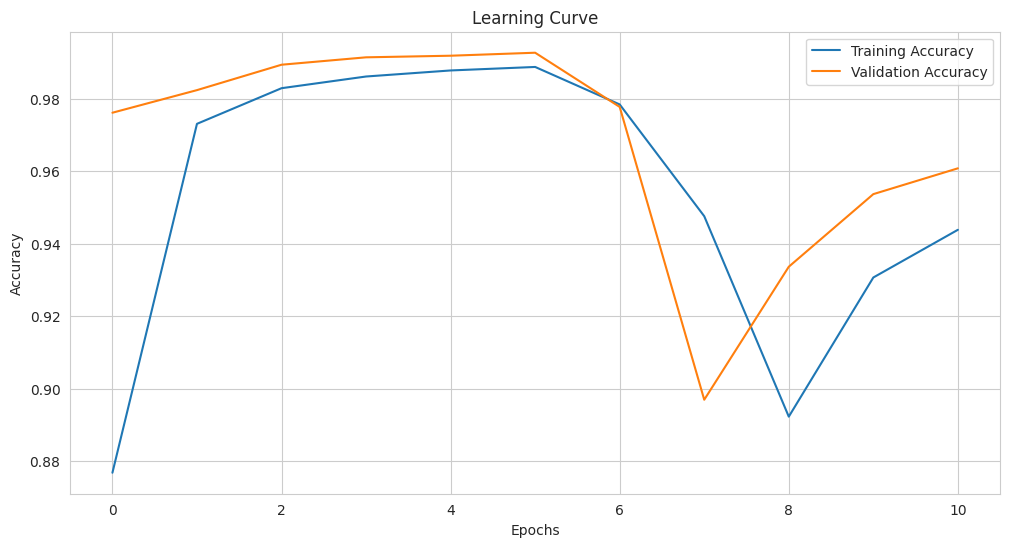

In [ ]:
callbacks = [
    TerminateOnNaN(),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]
bin_convlstm_history = binary_convlstm.fit(X_train_binary_seq_convLSTM_reshaped,
                                           y_train_binary_seq, epochs=20, batch_size=64,
                                           validation_data=(x_val_binary_seq_convLSTM_reshaped, y_val_binary_seq),
                                           callbacks=callbacks)
plot_learning_curve(bin_convlstm_history)

Epoch 1/25
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 38s 26ms/step - accuracy: 0.6141 - loss: 1.1539 - val_accuracy: 0.8476 - val_loss: 0.6700 - learning_rate: 0.0010
Epoch 2/25
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.8383 - loss: 0.4484 - val_accuracy: 0.8573 - val_loss: 0.3904 - learning_rate: 0.0010
Epoch 3/25
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.8504 - loss: 0.4062 - val_accuracy: 0.8678 - val_loss: 0.3592 - learning_rate: 0.0010
Epoch 4/25
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - accuracy: 0.8585 - loss: 0.3794 - val_accuracy: 0.8718 - val_loss: 0.3463 - learning_rate: 0.0010
Epoch 5/25
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - accuracy: 0.8620 - loss: 0.3680 - val_accuracy: 0.8710 - val_loss: 0.9448 - learning_rate: 0.0010
Epoch 6/25
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - accuracy: 0.8630 - loss: 0.3816 - val_accuracy: 0.8747 - val_loss: 0.4856 - learning_rate: 0.0010
Epoch 7/25
1029/1029 ━━━━━━━━━━━━━━━━━━━━ 40s 23ms/step - accura

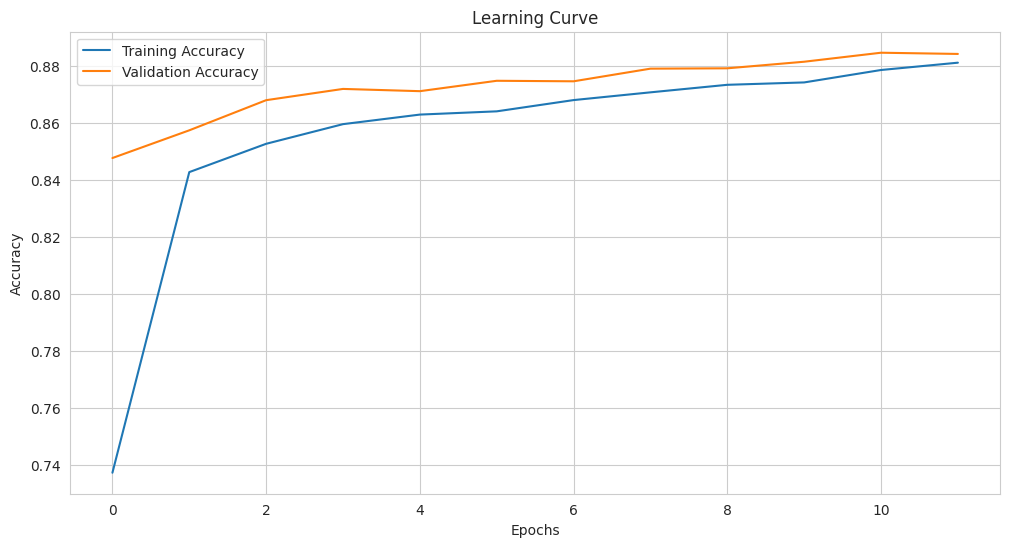

In [ ]:
multi_convlstm_history = multi_convlstm.fit(X_train_multi_seq_convLSTM_reshaped,
                                            y_train_multi_seq, epochs=25, batch_size=64,
                                            validation_data=(x_val_multi_seq_convLSTM_reshaped, y_val_multi_seq),
                                            callbacks=callbacks)
plot_learning_curve(multi_convlstm_history)

### Model Evaluation

* Examine your models (coefficients, parameters, errors, etc...)

* Compute and interpret your results in terms of accuracy, precision, recall, ROC etc.

5480/5480 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step
              precision    recall  f1-score   support

     Class 0       0.35      0.95      0.51     55991
     Class 1       0.89      0.17      0.29    119341

    accuracy                           0.42    175332
   macro avg       0.62      0.56      0.40    175332
weighted avg       0.72      0.42      0.36    175332



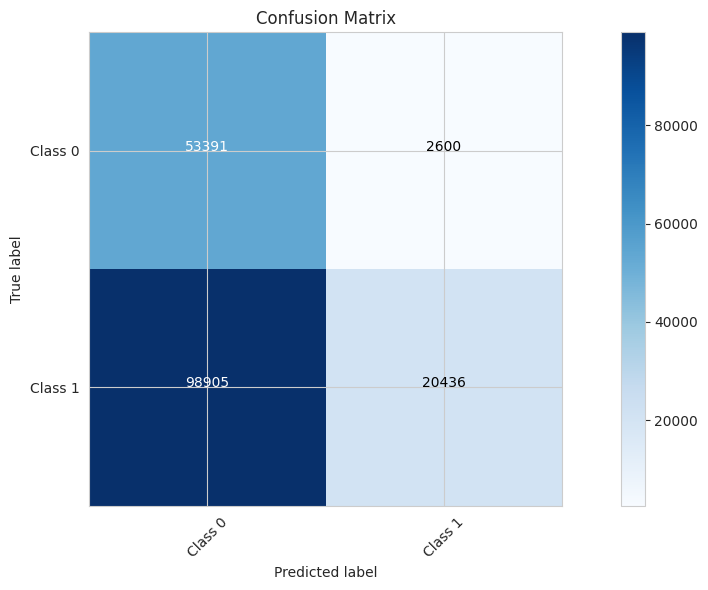

Test Accuracy: 0.42%
Test Precision: 0.89%
Test Recall: 0.17%
Test F1 Score: 0.29%


In [ ]:
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix

# C-LSTM evaluation
# Binary
y_pred_probs = binary_convlstm.predict(X_test_binary_seq)
y_pred = (y_pred_probs > 0.5).astype(int)
evaluate_binary_model(y_test_binary_seq, y_pred)
metrics = evaluate_model(y_test_binary_seq, y_pred_probs, binary=True)
metrics['Model'] = 'binary_clstm'
metrics_row = pd.DataFrame(metrics, index=[0])
metrics_df = pd.concat([metrics_df, metrics_row], ignore_index=True)

5480/5480 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
                precision    recall  f1-score   support

      Analysis       0.05      0.04      0.05      2000
      Backdoor       0.06      0.12      0.08      1746
           DoS       0.07      0.04      0.05     12264
      Exploits       0.66      0.14      0.23     33393
       Fuzzers       0.45      0.11      0.17     18184
       Generic       0.00      0.00      0.00     40000
        Normal       0.31      0.75      0.44     55991
Reconnaissance       0.47      0.16      0.23     10491
     Shellcode       0.03      0.32      0.06      1133
         Worms       0.02      0.31      0.04       130

      accuracy                           0.29    175332
     macro avg       0.21      0.20      0.14    175332
  weighted avg       0.31      0.29      0.22    175332



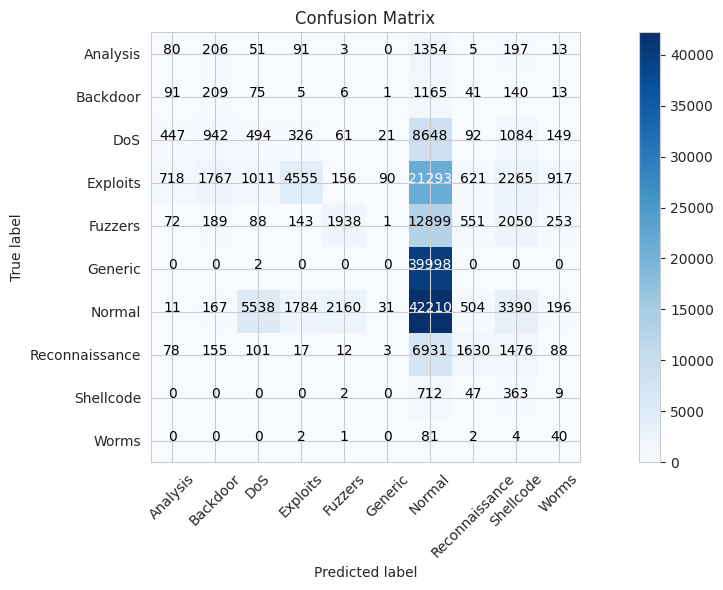

Test Accuracy: 0.29%
Test Precision: 0.21%
Test Recall: 0.20%
Test F1 Score: 0.14%
Test AUC: 0.51%


In [ ]:
# C-LSTM evaluation
# Multi-class
y_pred_probs = clstm_multi.predict(X_test_multi_seq)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = [attack_le.inverse_transform([i])[0] for i in range(len(attack_le.classes_))]
evaluate_multiclass_model(y_test_multi_seq, y_pred, class_names)
metrics = evaluate_model(y_test_multi_seq, y_pred_probs, binary=False)
metrics['Model'] = 'multi_clstm'
metrics_row = pd.DataFrame(metrics, index=[0])
metrics_df = pd.concat([metrics_df, metrics_row], ignore_index=True)

5480/5480 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step
              precision    recall  f1-score   support

     Class 0       0.40      0.96      0.56     55991
     Class 1       0.95      0.32      0.48    119341

    accuracy                           0.52    175332
   macro avg       0.67      0.64      0.52    175332
weighted avg       0.77      0.52      0.51    175332



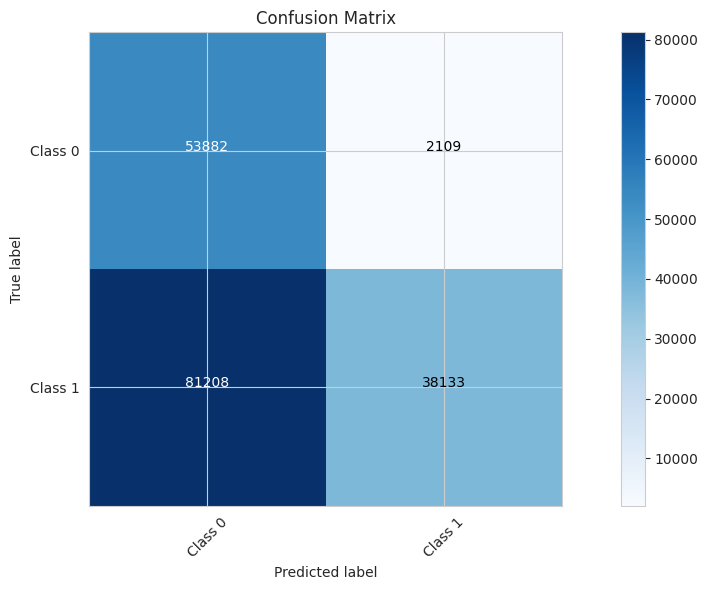

Test Accuracy: 0.52%
Test Precision: 0.95%
Test Recall: 0.32%
Test F1 Score: 0.48%


In [ ]:
# Evaluate convLSTM1D models
# Binary
y_pred_probs = binary_convlstm.predict(X_test_binary_seq_convLSTM_reshaped)
y_pred = (y_pred_probs > 0.5).astype(int)
evaluate_binary_model(y_test_binary_seq, y_pred)
metrics = evaluate_model(y_test_binary_seq, y_pred_probs, binary=True)
metrics['Model'] = 'binary_convlstm'
metrics_row = pd.DataFrame(metrics, index=[0])
metrics_df = pd.concat([metrics_df, metrics_row], ignore_index=True)

5480/5480 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step
                precision    recall  f1-score   support

      Analysis       0.00      0.00      0.00      2000
      Backdoor       0.00      0.00      0.00      1746
           DoS       0.26      0.03      0.05     12264
      Exploits       0.64      0.16      0.26     33393
       Fuzzers       0.24      0.02      0.04     18184
       Generic       0.90      0.04      0.09     40000
        Normal       0.34      0.96      0.50     55991
Reconnaissance       0.51      0.15      0.23     10491
     Shellcode       0.59      0.03      0.05      1133
         Worms       0.00      0.00      0.00       130

      accuracy                           0.36    175332
     macro avg       0.35      0.14      0.12    175332
  weighted avg       0.51      0.36      0.25    175332



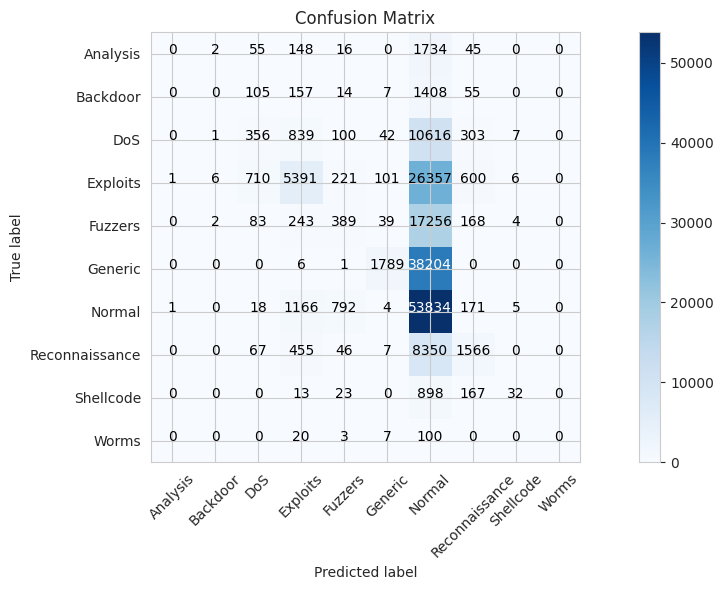

Test Accuracy: 0.36%
Test Precision: 0.35%
Test Recall: 0.14%
Test F1 Score: 0.12%
Test AUC: 0.55%


In [ ]:
# Evaluate convLSTM1D models
# Multi-class
y_pred_probs = multi_convlstm.predict(X_test_multi_seq_convLSTM_reshaped)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = [attack_le.inverse_transform([i])[0] for i in range(len(attack_le.classes_))]
evaluate_multiclass_model(y_test_multi_seq, y_pred, class_names)
metrics = evaluate_model(y_test_multi_seq, y_pred_probs, binary=False)
metrics['Model'] = 'multi_convlstm'
metrics_row = pd.DataFrame(metrics, index=[0])
metrics_df = pd.concat([metrics_df, metrics_row], ignore_index=True)

In [ ]:
# Show all metrics for comparison
metrics_df

,accuracy,precision,recall,f1_score,AUC,Model
0,0.390790,0.758023,0.154188,0.256253,0.524639,baseline_binary_dense_model
1,0.375927,0.795814,0.111822,0.196091,0.525335,baseline_binary_cnn_model
2,0.381887,0.797053,0.123277,0.213528,0.528187,baseline_binary_lstm_model
3,0.439275,0.819652,0.225907,0.354194,0.559981,baseline_binary_clstm_model
4,0.351516,0.335596,0.211038,0.157184,0.703012,baseline_multi_dense_model
5,0.482296,0.258141,0.305031,0.201116,0.767528,baseline_multi_cnn_model
6,0.374495,0.364399,0.210234,0.178224,0.754075,baseline_multi_lstm_model
7,0.551787,0.316688,0.324647,0.253591,0.838850,baseline_multi_clstm_model
8,0.373235,0.667994,0.157414,0.254788,0.557283,C-BiLSTM_Binary
9,0.333715,0.360336,0.333715,0.238408,0.702825,C-BiLSTM_Multi


In [ ]:
# Save all of the models
import joblib

# Set custom local dir for saving
local_dir = './drive/MyDrive/Colab Notebooks/Penn State Deep Learning'

# CLSTM
joblib.dump(clstm_binary, f'{local_dir}/clstm_binary.pkl')
joblib.dump(clstm_multi, f'{local_dir}/clstm_multi.pkl')

# Bi-CLSTMs
joblib.dump(binary_cbilstm, f'{local_dir}/binary_cbilstm.pkl')
joblib.dump(multi_cbilstm, f'{local_dir}/multi_cbilstm.pkl')

# ConvLSTM
joblib.dump(binary_convlstm, f'{local_dir}/binary_convlstm.pkl')
joblib.dump(multi_convlstm, f'{local_dir}/multi_convlstm.pkl')

print("Models saved.")


Models saved.


### Issues / Improvements
1. Evaluate SMOTE vs no SMOTE for all model types
2. Evaluate using cross-validation
3. Explore class balancing techniques further, e.g., different weighting
4. Examine if different loss functions would perform better
5. Ensemble methos: Could we add the binary model output to the multi-class model to improve performance? Other ensembles?

###  References
   - Please see paper for references


In [ ]:
# End of Project